# Variational Autoencoders — PyTorch Pipeline

Closes the **generative arc** opened by Autoencoders #10 and GANs #14 with a third philosophy on the same image domain: **explicit probabilistic latent**, likelihood-based training (ELBO), and the discrete-latent lineage (VQ-VAE) that powers modern generative AI. Four variants on two datasets:

- **MNIST** (teaching): V1 Vanilla VAE + V3 β-VAE for latent visualization and disentanglement
- **CIFAR-10** (portfolio): V2 Conv VAE + V4 VQ-VAE for direct FID comparison against GAN #14's DCGAN 30.57

---

## Background: Why VAEs Matter

### What problem they solve

Prior generative models in this portfolio had clear trade-offs:

- **Autoencoders #10** compress input to a deterministic latent then reconstruct. The latent is useful for classification (KNN on latent hit 36.21% on CIFAR-10) but you can't *generate* — sampling a random latent produces garbage because the AE never learned what latent points are "valid."
- **GANs #14** generate beautifully (DCGAN FID 30.57 on CIFAR-10) but have no explicit likelihood. You can't ask "how probable is this image?" or "what's the evidence lower bound?" Training is adversarial, notoriously unstable, and mode collapse is a constant risk.

VAE splits the difference: a **probabilistic encoder** outputs a distribution (mean + variance) over latent space, a sample is drawn via the reparameterization trick, and a **decoder** reconstructs from the sample. Training maximizes the **Evidence Lower Bound (ELBO)** — a tractable lower bound on `log p(x)`:

```text
ELBO(x)  =  E_{z ~ q(z|x)} [ log p(x|z) ]   -   KL( q(z|x) || p(z) )

            ^^^ reconstruction term ^^^        ^^^ KL regularization term ^^^
            (decoder fits input)               (latent stays near N(0, I))
```

- **Reconstruction term** — same as AE: decoder output close to input
- **KL term** — encoder's `q(z|x)` stays close to prior `p(z) = N(0, I)`; this is what makes the latent space "samplable"

The **reparameterization trick** is the elegance: instead of sampling `z ~ N(μ, σ²)` directly (can't backprop through), write `z = μ + σ·ε` where `ε ~ N(0, I)` is noise. Now gradients flow through μ and σ as learned parameters.

### When to reach for a VAE

**Use a VAE when**:
- You need a meaningful latent space (classification, retrieval, anomaly detection, interpolation)
- Exact likelihood matters (density estimation, outlier detection, compression)
- You need stable training (no adversarial dynamics)
- You're building a two-stage system where VAE compresses and another model operates on codes (Stable Diffusion, DALL-E 1, EnCodec)

**Don't use a VAE when**:
- Sample quality is the top priority -> GAN or diffusion wins
- Latent dimension matters more than visual fidelity -> use AE or contrastive encoder
- You need exact discrete codes without a commitment loss -> use finite-state or hash encoder

### Real-world impact

**The foundation of modern generative AI runs on VAE descendants**:

- **Stable Diffusion** (Rombach et al. 2022) trains a VAE to compress 512×512 images into 64×64×4 latents, THEN runs diffusion in latent space. Without the VAE stage, diffusion on raw pixels would need 64x more compute.
- **DALL-E 1** (Ramesh et al. 2021) used a **VQ-VAE** (our V4) to tokenize 256×256 images into 32×32 discrete codes. The Transformer then treated image generation as token prediction. Modern successors (DALL-E 2/3, Muse) still use the discrete-VAE architecture.
- **EnCodec** (Défossez et al. 2022, Meta AI) — residual VQ-VAE for neural audio compression, used by MusicGen / AudioGen. Same VQ-VAE primitive, different domain.
- **β-VAE** (Higgins et al. 2017) — established disentanglement as a research agenda; descendants FactorVAE, MONet, IODINE all build on the β weighting idea.

Every generative-AI company in 2026 has a VAE somewhere in the stack.

---

## Task: Generate + Reconstruct Two Image Datasets

| Dataset | Images | Size | Purpose |
|---------|--------|------|---------|
| MNIST | 60K train / 10K test | 28×28 grayscale | Canonical teaching — 2D latent visualization, digit morphing, β-disentanglement |
| CIFAR-10 | 50K train / 10K test | 32×32 RGB | Portfolio hero — FID comparison vs GAN #14, VQ-VAE discrete-latent showcase |

Both normalized to `[0, 1]` (diverges from GAN #14's `[-1, 1]`) — matches VAE's Bernoulli/Gaussian decoder likelihood conventions.

## Five Variants (isolating distinct levers)

| # | Variant | Dataset | From scratch? | Lever isolated |
|---|---------|---------|---------------|----------------|
| V1 | Vanilla VAE (Kingma & Welling 2013) | MNIST | Yes (MLP + reparameterization) | Baseline probabilistic latent + ELBO |
| V2 | Conv VAE | CIFAR-10 | Yes (Conv + ConvTranspose, mirrors AE #10) | Image-quality architecture + FID vs GAN |
| V3 | β-VAE (Higgins et al. 2017) | MNIST | Yes (V1 + β·KL weighting, sweep β∈{1,4,10}) | **Disentanglement** — visible via latent traversals |
| V4 | **VQ-VAE** (van den Oord et al. 2017) | CIFAR-10 | Yes (codebook + straight-through estimator) | **Discrete latents** — foundation of DALL-E 1 / Stable Diffusion |
| V5 | **VQ-VAE + PixelCNN prior** (van den Oord 2016, 2017) | CIFAR-10 | Yes (masked Conv2d + autoregressive raster sampling over V4's codes) | **Autoregressive prior over discrete tokens** — completes the DALL-E 1 two-stage recipe (VQ encoder -> learned prior -> VQ decoder) |

All variants built from `nn.Linear` / `nn.Conv2d` / `nn.ConvTranspose2d` / `nn.Embedding` primitives. No `torch.distributions`, no pre-built VAE classes. The reparameterization trick + KL divergence + VQ straight-through estimator + masked-convolution causality all implemented directly.

## Evaluation Strategy

- **Reconstruction MSE** — direct comparison to AE #10's 0.0037 (AE is deterministic; VAE will be slightly higher because of KL pressure)
- **FID vs real images** — direct comparison to GAN #14's DCGAN 30.57 on CIFAR-10 (V2, V4, V5 — MNIST is grayscale, FID convention is RGB). V5 stacks the full ladder: random-code FID (floor) < prior-sampled FID (learned) < reconstruction FID (ceiling) < GAN
- **Test NLL (nats)** — likelihood-based VAE metric; canonical reporting unit from Kingma 2013
- **Prior cross-entropy (nats/position)** — V5 PixelCNN measure of how tightly the prior models the discrete code distribution; uniform baseline is ln(K) = ln(512) ≈ 6.24 nats
- **Latent traversals** — V3 β-VAE core deliverable; varies one latent dim while fixing others to visualize disentanglement
- **Latent interpolation** — morph one sample into another through latent space; shows whether the latent is geometrically smooth
- **Codebook perplexity** — V4 VQ-VAE health metric; should use most of the 512 codes
- **Best-val-snapshot test eval** — standard transductive convention, matches GNN #18

## Pipeline Steps

1. Setup + load both datasets
2. V1 Vanilla VAE on MNIST (MLP encoder/decoder, 20-dim latent, 50 epochs)
3. V2 Conv VAE on CIFAR-10 (Conv+ConvTranspose, 64-dim latent, 100 epochs, FID evaluation)
4. V3 β-VAE on MNIST (β sweep {1, 4, 10}, disentanglement traversals)
5. V4 VQ-VAE on CIFAR-10 (512-code codebook, dim 64, straight-through estimator, 100 epochs)
6. V5 VQ-VAE + PixelCNN prior on CIFAR-10 (masked convolutions, autoregressive sampling, prior-FID vs GAN #14 ladder)
7. Cross-variant comparison tables: MNIST (V1 + V3) + CIFAR-10 (V2 + V4 + V5), VAE-vs-GAN FID ladder
8. Winner selection per dataset with rationale
9. MLflow tracking (vae-mnist + vae-cifar10 experiments, PT checkpoints + key PNGs)
10. Cross-framework JSON persistence (add_result for vae_mnist + vae_cifar10)

In [1]:
# Step 1: Setup + Data Loading

# Standard lib
import sys
from pathlib import Path

# Scientific / plotting
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Project root on path
PROJECT_ROOT = Path('../..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

# Metrics: evaluate_classifier returns {accuracy, macro_f1, ...} from raw labels.
#          Used for KNN-on-latent evaluation (AE #10 convention).
from utils.metrics import evaluate_classifier, print_metrics

# Performance: context manager + inference timer
from utils.performance import track_performance, track_inference

# Results persistence (cross-framework JSONs)
from utils.results import build_results_dict, add_result, print_comparison

# Viz: plot utilities take raw arrays; compute stats internally
from utils.visualization import (
    plot_generated_grid,
    plot_latent_space,
    plot_training_history,
)

# Generative-model FID (shared with GANs #14 for apples-to-apples CIFAR comparison)
from utils.gan_utils import compute_fid

"""
VAE primitives (new utility module)
  reparameterize:         (mu, logvar) -> z = mu + eps * exp(0.5 * logvar)
  kl_divergence_gaussian: (mu, logvar) -> per-sample KL vs N(0, I)
  vq_straight_through:    (z_e, codebook) -> (z_q, indices), with ST gradient
  vq_commit_loss:         (z_e, z_q, beta=0.25) -> scalar commitment loss
  latent_traversal:       (decoder, base_z, dim, n_steps, range_) -> (n_steps, *img)
  interpolate_latent:     (decoder, z1, z2, n_steps) -> (n_steps, *img)
"""
from utils.vae_utils import (
    reparameterize,
    kl_divergence_gaussian,
    vq_straight_through,
    vq_commit_loss,
    latent_traversal,
    interpolate_latent,
)

# Reproducibility
RANDOM_STATE = 113
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.backends.cudnn.benchmark = True  # faster fixed-shape training on RTX 4090

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE} "
      f"({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# Data paths
DATA_ROOT = PROJECT_ROOT / 'data' / 'processed' / 'vae'
MNIST_DIR = DATA_ROOT / 'mnist'
CIFAR_DIR = DATA_ROOT / 'cifar10'

# Class names (loaded from preprocessing_info.json via direct read)
import json
with open(MNIST_DIR / 'preprocessing_info.json') as f:
    MNIST_CLASS_NAMES = json.load(f)['class_names']
with open(CIFAR_DIR / 'preprocessing_info.json') as f:
    CIFAR_CLASS_NAMES = json.load(f)['class_names']

# Results dir for this pipeline's artifacts (checkpoints, PNGs, comparison JSON)
RESULTS_DIR = Path('./results')
RESULTS_DIR.mkdir(exist_ok=True)

# In-notebook variant containers (Phase 8 cross-variant cell reads these)
mnist_variants = []    # V1 Vanilla, V3 beta-VAE per-beta entries
cifar_variants = []    # V2 Conv VAE, V4 VQ-VAE


# Load MNIST as PyTorch tensors. Add channel dim: (N, 28, 28) -> (N, 1, 28, 28)
mnist_X_train = torch.from_numpy(np.load(MNIST_DIR / 'X_train.npy')).unsqueeze(1)
mnist_X_test  = torch.from_numpy(np.load(MNIST_DIR / 'X_test.npy')).unsqueeze(1)
mnist_y_train = torch.from_numpy(np.load(MNIST_DIR / 'y_train.npy')).long()
mnist_y_test  = torch.from_numpy(np.load(MNIST_DIR / 'y_test.npy')).long()


# Load CIFAR-10 and convert channel-last -> channel-first
# (N, 32, 32, 3) -> (N, 3, 32, 32) for PyTorch conv conventions
cifar_X_train = torch.from_numpy(np.load(CIFAR_DIR / 'X_train.npy')).permute(0, 3, 1, 2).contiguous()
cifar_X_test  = torch.from_numpy(np.load(CIFAR_DIR / 'X_test.npy')).permute(0, 3, 1, 2).contiguous()
cifar_y_train = torch.from_numpy(np.load(CIFAR_DIR / 'y_train.npy')).long()
cifar_y_test  = torch.from_numpy(np.load(CIFAR_DIR / 'y_test.npy')).long()

print("=" * 60)
print("VAE - PyTorch Pipeline Setup Complete")
print("=" * 60)

print(f"\nMNIST (added channel dim, on CPU):")
print(f"    X_train: {tuple(mnist_X_train.shape)} {mnist_X_train.dtype}")
print(f"    X_test:  {tuple(mnist_X_test.shape)}  {mnist_X_test.dtype}")
print(f"    Range:   [{mnist_X_train.min():.2f}, {mnist_X_train.max():.2f}]")
print(f"    Classes: {len(MNIST_CLASS_NAMES)}")

print(f"\nCIFAR-10 (channel-first, on CPU):")
print(f"    X_train: {tuple(cifar_X_train.shape)} {cifar_X_train.dtype}")
print(f"    X_test:  {tuple(cifar_X_test.shape)}  {cifar_X_test.dtype}")
print(f"    Range:   [{cifar_X_train.min():.2f}, {cifar_X_train.max():.2f}]")
print(f"    Classes: {len(CIFAR_CLASS_NAMES)}")

print(f"\nResults dir: {RESULTS_DIR.resolve()}")

Device: cuda (NVIDIA GeForce RTX 4090)
VAE - PyTorch Pipeline Setup Complete

MNIST (added channel dim, on CPU):
    X_train: (60000, 1, 28, 28) torch.float32
    X_test:  (10000, 1, 28, 28)  torch.float32
    Range:   [0.00, 1.00]
    Classes: 10

CIFAR-10 (channel-first, on CPU):
    X_train: (50000, 3, 32, 32) torch.float32
    X_test:  (10000, 3, 32, 32)  torch.float32
    Range:   [0.00, 1.00]
    Classes: 10

Results dir: C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\PyTorch\19-vae\results


In [2]:
# Step 2: Vanilla VAE class + ELBO loss

"""
Kingma & Welling (2013) MLP VAE for MNIST. Single hidden layer
of 400 units, 20-dim latent by default (2-dim option for 2D scatter
visualization). Canonical "Hello World" VAE architecture.

Encoder: flatten(x) -> Linear(784 -> 400) -> ReLU -> (mu, logvar) heads
Decoder: z -> Linear(20 -> 400) -> ReLU -> Linear(400 -> 784) -> Sigmoid

Loss = ELBO (negated for minimization):
    L = BCE(x_recon, x) + beta * KL(N(mu, sigma^2) || N(0, I))

BCE is appropriate because MNIST is bimodal (~82% pixels near 0, ~8% near 1
per Phase 2 EDA) -- Bernoulli decoder likelihood matches the data. Sigmoid
output keeps x_recon in [0, 1] for the BCE input range. Beta defaulted to 1.0
for V1.
"""


class VAELinear(nn.Module):
    """
    MLP VAE. Single hidden layer. Separate mu/logvar heads at encoder output.

    Args:
        input_dim:  flattened image size (MNIST: 784 = 28*28).
        hidden_dim: hidden layer width (Kingma paper uses 400-500; 400 here).
        latent_dim: bottleneck dim (20 canonical, 2 for visualization).
    """

    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        # Encoder: input -> hidden -> (mu, logvar) heads
        self.enc_fc1 = nn.Linear(input_dim, hidden_dim)
        self.enc_mu = nn.Linear(hidden_dim, latent_dim)
        self.enc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder: latent -> hidden -> output
        self.dec_fc1 = nn.Linear(latent_dim, hidden_dim)
        self.dec_fc2 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        # Flatten input, return (mu, logvar)
        x_flat = x.view(x.size(0), -1)
        h = F.relu(self.enc_fc1(x_flat))
        return self.enc_mu(h), self.enc_logvar(h)

    def decode(self, z):
        # Decode latent z to Sigmoid-bounded pixel reconstruction (flat)
        h = F.relu(self.dec_fc1(z))
        return torch.sigmoid(self.dec_fc2(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


def vae_loss(x_recon, x, mu, logvar, beta=1.0):
    """
    ELBO-derived loss (to be minimized). Returns (total, recon_component, kl_component).

    total = BCE(x_recon, x) + beta * KL(N(mu, sigma^2) || N(0, I))

    BCE reduction strategy: sum over pixels, mean over batch.
    Matches Kingma 2013 paper's convention where per-sample NLL is reported in nats.

    Args:
        x_recon: (B, input_dim) sigmoid-bounded reconstruction.
        x:       (B, C, H, W) or (B, input_dim) original input in [0, 1].
        mu:      (B, latent_dim).
        logvar:  (B, latent_dim).
        beta:    KL weight (1.0 for vanilla VAE; will be swept in V3).

    Returns:
        loss, recon, kl: scalar tensors (all per-sample, averaged over batch).
    """
    x_flat = x.view(x.size(0), -1)
    # BCE: sum over pixels, mean over batch (nats per sample for pixel reconstruction)
    recon = F.binary_cross_entropy(x_recon, x_flat, reduction='sum') / x.size(0)
    # KL divergence: our util returns per-sample sum over latent dims; mean over batch
    kl = kl_divergence_gaussian(mu, logvar).mean()
    loss = recon + beta * kl
    return loss, recon, kl


# Sanity test: build a 20-dim-latent VAE, run one batch, check shapes + param count
_test_batch = mnist_X_train[:16].to(DEVICE)  # (16, 1, 28, 28)
_test_model = VAELinear(input_dim=784, hidden_dim=400, latent_dim=20).to(DEVICE)
_test_model.eval()
with torch.no_grad():
    _x_recon, _mu, _logvar = _test_model(_test_batch)
    _loss, _recon, _kl = vae_loss(_x_recon, _test_batch, _mu, _logvar, beta=1.0)

print(f"VAELinear sanity test on MNIST:")
print(f"    Input x:        {tuple(_test_batch.shape)}  {_test_batch.dtype}  device={_test_batch.device.type}")
print(f"    x_recon:        {tuple(_x_recon.shape)}    (flat 784-dim sigmoid)")
print(f"    mu:             {tuple(_mu.shape)}    logvar: {tuple(_logvar.shape)}")
print(f"    Untrained loss: {_loss.item():.2f} nats/sample  "
      f"(recon={_recon.item():.2f}, kl={_kl.item():.2f})")
print(f"    Total params:   {sum(p.numel() for p in _test_model.parameters()):,}")

del _test_batch, _test_model, _x_recon, _mu, _logvar, _loss, _recon, _kl
torch.cuda.empty_cache()

VAELinear sanity test on MNIST:
    Input x:        (16, 1, 28, 28)  torch.float32  device=cuda
    x_recon:        (16, 784)    (flat 784-dim sigmoid)
    mu:             (16, 20)    logvar: (16, 20)
    Untrained loss: 548.42 nats/sample  (recon=548.34, kl=0.08)
    Total params:   652,824


Train: 54,000, Val: 6,000, Test: 10,000
Model: VAELinear(in=784, hidden=400, latent=20), 652,824 params

Training V1 Vanilla VAE on MNIST (50 epochs)...
    ep  1: train_loss=168.43  (recon=153.63, kl=14.80) | val_loss=131.57  (recon=111.78, kl=19.80)
    ep  5: train_loss=110.23  (recon=85.85, kl=24.38) | val_loss=110.30  (recon=86.30, kl=24.00)
    ep 10: train_loss=106.42  (recon=81.45, kl=24.97) | val_loss=107.31  (recon=82.45, kl=24.86)
    ep 15: train_loss=104.87  (recon=79.75, kl=25.13) | val_loss=106.24  (recon=81.00, kl=25.24)
    ep 20: train_loss=104.09  (recon=78.86, kl=25.23) | val_loss=105.22  (recon=79.64, kl=25.59)
    ep 25: train_loss=103.49  (recon=78.21, kl=25.28) | val_loss=104.73  (recon=79.44, kl=25.29)
    ep 30: train_loss=103.03  (recon=77.73, kl=25.30) | val_loss=104.15  (recon=79.23, kl=24.92)
    ep 35: train_loss=102.67  (recon=77.36, kl=25.31) | val_loss=104.04  (recon=78.53, kl=25.51)
    ep 40: train_loss=102.27  (recon=77.02, kl=25.26) | val_loss=103.

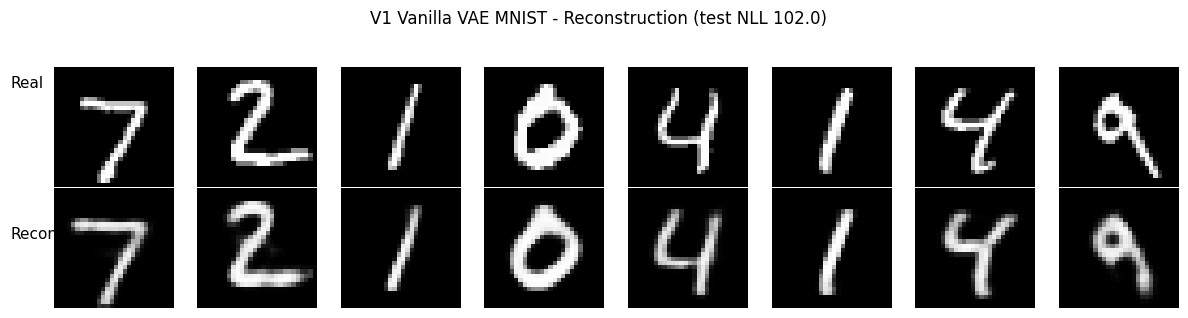

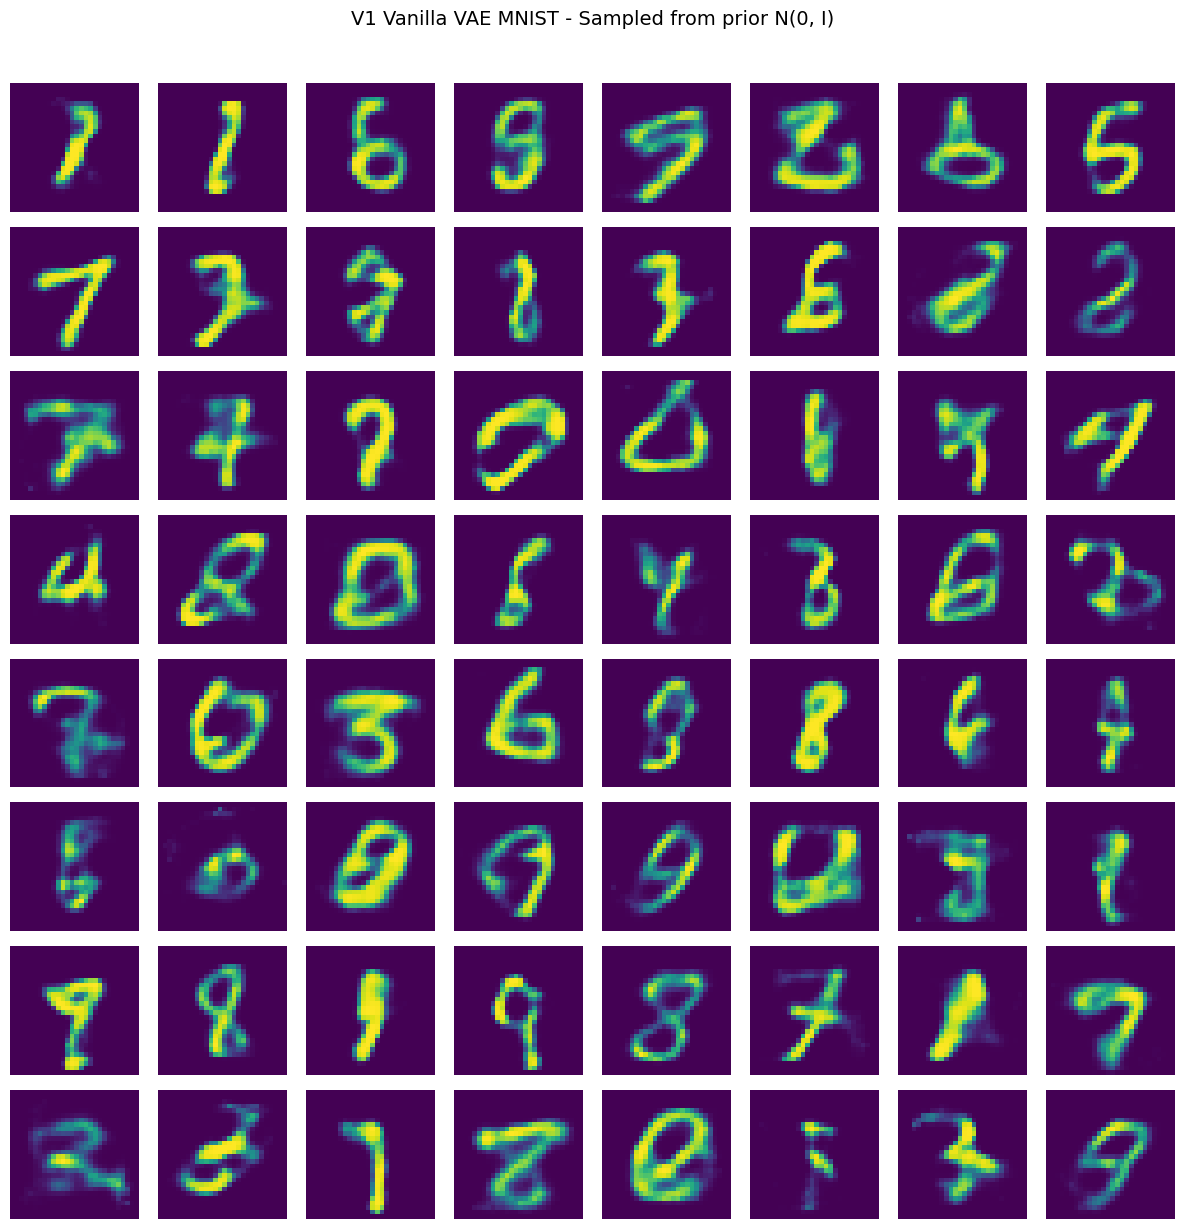

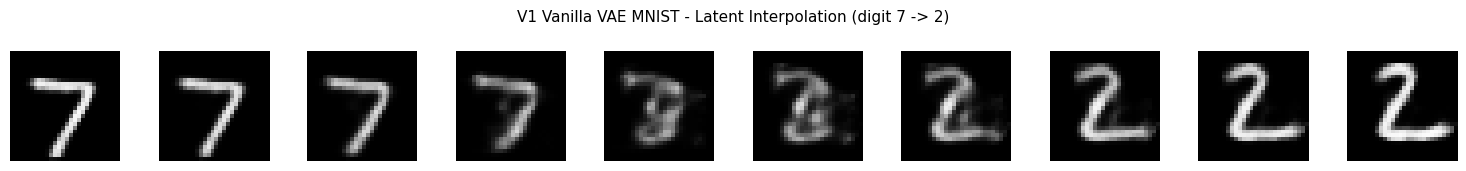

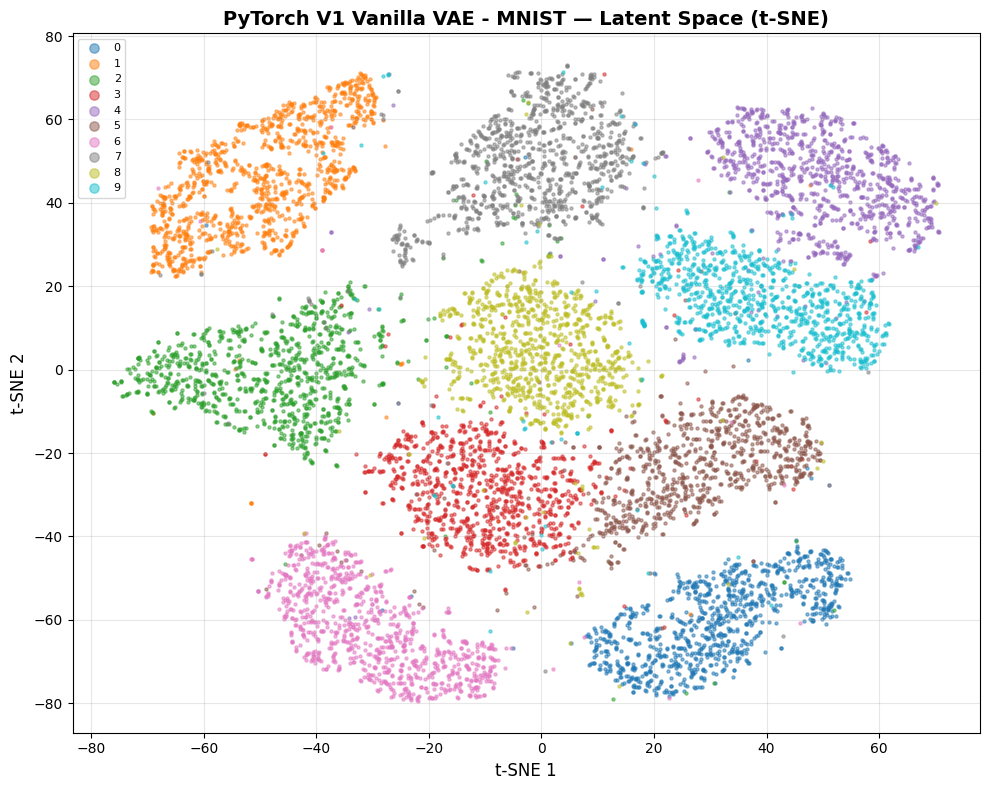

    Inference: 1.69 us/sample, 591,197 samples/sec


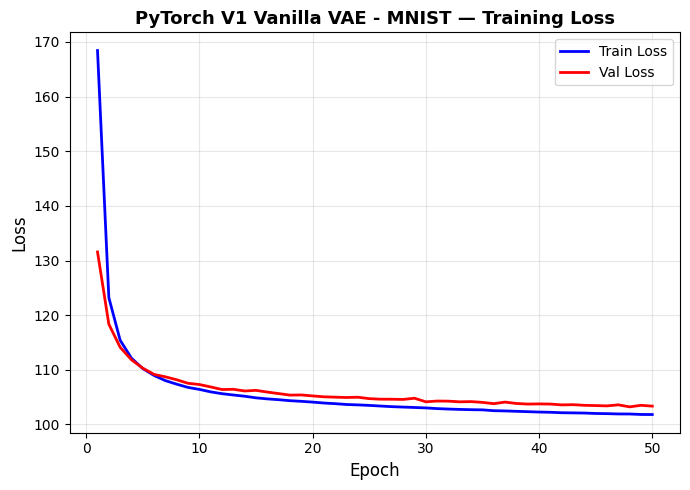


    Checkpoint: results\v1_vanilla_mnist_best.pth
    Model size: 2550.1 KB, params: 652,824


In [3]:
# Step 3: V1 Vanilla VAE on MNIST (training + test + viz)

"""
Kingma & Welling 2013 recipe: 20-dim latent, Adam(lr=1e-3), 50 epochs,
batch_size=128. Best-val-NLL snapshot for test eval.

Val carved from train (10% = 6K samples) with seeded permutation.
Test NLL reported as ELBO-derived value in nats/sample (paper ~82).
"""

# V1 MNIST hyperparameters (Kingma 2013)
V1_INPUT_DIM = 784
V1_HIDDEN_DIM = 400
V1_LATENT_DIM = 20
V1_BETA = 1.0
V1_LR = 1e-3
V1_BATCH_SIZE = 128
V1_EPOCHS = 50
V1_LOG_EVERY = 5
V1_VAL_FRAC = 0.1


# Train/val split (seeded, deterministic)
n_train_full = len(mnist_X_train)
n_val = int(V1_VAL_FRAC * n_train_full)

split_gen = torch.Generator().manual_seed(RANDOM_STATE)
perm = torch.randperm(n_train_full, generator=split_gen)
val_idx, train_idx = perm[:n_val], perm[n_val:]

train_loader = DataLoader(
    TensorDataset(mnist_X_train[train_idx]),
    batch_size=V1_BATCH_SIZE, shuffle=True,
    generator=torch.Generator().manual_seed(RANDOM_STATE),
)
val_loader = DataLoader(
    TensorDataset(mnist_X_train[val_idx]),
    batch_size=V1_BATCH_SIZE, shuffle=False,
)
test_loader = DataLoader(
    TensorDataset(mnist_X_test),
    batch_size=V1_BATCH_SIZE, shuffle=False,
)
print(f"Train: {len(train_idx):,}, Val: {len(val_idx):,}, Test: {len(mnist_X_test):,}")


# Model + optimizer
torch.manual_seed(RANDOM_STATE)
model_v1 = VAELinear(V1_INPUT_DIM, V1_HIDDEN_DIM, V1_LATENT_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model_v1.parameters(), lr=V1_LR)
num_params = sum(p.numel() for p in model_v1.parameters())
print(f"Model: VAELinear(in={V1_INPUT_DIM}, hidden={V1_HIDDEN_DIM}, latent={V1_LATENT_DIM}), "
      f"{num_params:,} params")


# Training with best-val-NLL snapshot
history = {
    'train_loss': [], 'train_recon': [], 'train_kl': [],
    'val_loss': [], 'val_recon': [], 'val_kl': [],
}
best_val = float('inf')
best_state = None

print(f"\nTraining V1 Vanilla VAE on MNIST ({V1_EPOCHS} epochs)...")
with track_performance(gpu=True) as perf:
    for epoch in range(V1_EPOCHS):
        # Train
        model_v1.train()
        tl = tr = tk = 0.0
        n = 0
        for (x,) in train_loader:
            x = x.to(DEVICE)
            optimizer.zero_grad()
            x_recon, mu, logvar = model_v1(x)
            loss, recon, kl = vae_loss(x_recon, x, mu, logvar, beta=V1_BETA)
            loss.backward()
            optimizer.step()
            b = x.size(0)
            tl += loss.item() * b; tr += recon.item() * b; tk += kl.item() * b
            n += b
        tl /= n; tr /= n; tk /= n

        # Val
        model_v1.eval()
        vl = vr = vk = 0.0
        n = 0
        with torch.no_grad():
            for (x,) in val_loader:
                x = x.to(DEVICE)
                x_recon, mu, logvar = model_v1(x)
                loss, recon, kl = vae_loss(x_recon, x, mu, logvar, beta=V1_BETA)
                b = x.size(0)
                vl += loss.item() * b; vr += recon.item() * b; vk += kl.item() * b
                n += b
        vl /= n; vr /= n; vk /= n

        for k, v in [('train_loss', tl), ('train_recon', tr), ('train_kl', tk),
                     ('val_loss', vl), ('val_recon', vr), ('val_kl', vk)]:
            history[k].append(v)

        if vl < best_val:
            best_val = vl
            best_state = {k: v.detach().clone() for k, v in model_v1.state_dict().items()}

        if (epoch + 1) % V1_LOG_EVERY == 0 or epoch == 0:
            print(f"    ep {epoch + 1:2d}: train_loss={tl:.2f}  (recon={tr:.2f}, kl={tk:.2f}) "
                  f"| val_loss={vl:.2f}  (recon={vr:.2f}, kl={vk:.2f})")

print(f"\n    Train time: {perf['time']:.1f}s, peak GPU memory: {perf['gpu_memory']:.1f} MB")
print(f"    Best val NLL: {best_val:.2f} nats/sample")


# Test eval with best-val weights
model_v1.load_state_dict(best_state)
model_v1.eval()

test_nll = test_recon = test_kl = 0.0
n = 0
test_mus = []
test_labels = []
with torch.no_grad():
    for (x,), y in zip(test_loader, DataLoader(
            TensorDataset(mnist_y_test), batch_size=V1_BATCH_SIZE, shuffle=False)):
        x = x.to(DEVICE)
        x_recon, mu, logvar = model_v1(x)
        loss, recon, kl = vae_loss(x_recon, x, mu, logvar, beta=V1_BETA)
        b = x.size(0)
        test_nll += loss.item() * b; test_recon += recon.item() * b; test_kl += kl.item() * b
        n += b
        test_mus.append(mu.cpu())
        test_labels.append(y[0])
test_nll /= n; test_recon /= n; test_kl /= n
test_mus = torch.cat(test_mus, dim=0).numpy()
test_labels = torch.cat(test_labels, dim=0).numpy()

print(f"\n    Test NLL:       {test_nll:.2f} nats/sample  "
      f"(recon={test_recon:.2f}, kl={test_kl:.2f})")
print(f"    Kingma 2013 ref: ~82 nats")


# Visualizations: reconstruction, samples, interpolation, latent t-SNE

# 1. Reconstruction grid (inline 2x8: real on top, recon on bottom)
x_sample = mnist_X_test[:8].to(DEVICE)
with torch.no_grad():
    x_recon_sample, _, _ = model_v1(x_sample)
x_recon_sample = x_recon_sample.view(-1, 1, 28, 28).cpu()
x_sample_cpu = x_sample.cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i in range(8):
    axes[0, i].imshow(x_sample_cpu[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].imshow(x_recon_sample[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')
fig.text(0.01, 0.75, 'Real', va='center', fontsize=11)
fig.text(0.01, 0.28, 'Recon', va='center', fontsize=11)
fig.suptitle(f'V1 Vanilla VAE MNIST - Reconstruction (test NLL {test_nll:.1f})',
             fontsize=12)
plt.tight_layout(rect=[0.03, 0, 1, 0.95])
plt.savefig(RESULTS_DIR / 'v1_vanilla_mnist_recon.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Generated samples (64 draws from prior, 8x8 grid)
torch.manual_seed(RANDOM_STATE)
with torch.no_grad():
    z_prior = torch.randn(64, V1_LATENT_DIM, device=DEVICE)
    samples = model_v1.decode(z_prior).view(-1, 28, 28).cpu().numpy()
plot_generated_grid(
    samples, nrow=8,
    title='V1 Vanilla VAE MNIST - Sampled from prior N(0, I)',
    save_path=str(RESULTS_DIR / 'v1_vanilla_mnist_samples.png'),
)

# 3. Latent interpolation (encode 2 test samples, morph through 10 steps)
x1 = mnist_X_test[0:1].to(DEVICE)
x2 = mnist_X_test[1:2].to(DEVICE)
with torch.no_grad():
    mu1, _ = model_v1.encode(x1)
    mu2, _ = model_v1.encode(x2)
interp = interpolate_latent(
    lambda z: model_v1.decode(z).view(-1, 1, 28, 28),
    mu1.squeeze(0), mu2.squeeze(0), n_steps=10,
).cpu()

fig, axes = plt.subplots(1, 10, figsize=(15, 1.7))
for i in range(10):
    axes[i].imshow(interp[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[i].axis('off')
fig.suptitle(
    f'V1 Vanilla VAE MNIST - Latent Interpolation '
    f'(digit {int(mnist_y_test[0])} -> {int(mnist_y_test[1])})',
    fontsize=11,
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'v1_vanilla_mnist_interp.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Latent t-SNE (entire test set, 20-dim -> 2D, colored by digit class)
plot_latent_space(
    test_mus, test_labels, MNIST_CLASS_NAMES,
    framework='PyTorch V1 Vanilla VAE - MNIST',
    method='tsne',
    save_path=str(RESULTS_DIR / 'v1_vanilla_mnist_latent_tsne.png'),
)


# Inference speed (full test set forward pass)
def _predict_v1(x_batch):
    with torch.no_grad():
        x_recon, _, _ = model_v1(x_batch.to(DEVICE))
    return x_recon.cpu()
inference_stats = track_inference(_predict_v1, mnist_X_test[:1024], n_runs=20)
print(f"    Inference: {inference_stats['per_sample_us']:.2f} us/sample, "
      f"{inference_stats['samples_per_sec']:,.0f} samples/sec")


# Log variant + checkpoint
plot_training_history(
    history,
    framework='PyTorch V1 Vanilla VAE - MNIST',
    save_path=str(RESULTS_DIR / 'v1_vanilla_mnist_history.png'),
)

model_size_bytes = sum(p.numel() * p.element_size() for p in model_v1.parameters())
mnist_variants.append({
    'variant': 'V1 Vanilla VAE',
    'dataset': 'MNIST',
    'test_nll': float(test_nll),
    'test_recon': float(test_recon),
    'test_kl': float(test_kl),
    'best_val_nll': float(best_val),
    'perf': perf,
    'inference_stats': inference_stats,
    'model_size_bytes': int(model_size_bytes),
    'num_params': int(num_params),
    'history': history,
    'hyperparams': {
        'latent_dim': V1_LATENT_DIM, 'hidden_dim': V1_HIDDEN_DIM,
        'beta': V1_BETA, 'lr': V1_LR, 'epochs': V1_EPOCHS,
    },
})

ckpt_path = RESULTS_DIR / 'v1_vanilla_mnist_best.pth'
torch.save(best_state, ckpt_path)
print(f"\n    Checkpoint: {ckpt_path}")
print(f"    Model size: {model_size_bytes / 1024:.1f} KB, params: {num_params:,}")

Train: 45,000, Val: 5,000, Test: 10,000
Model: VAEConv(in=3, latent=64), 581,763 params
Sanity: x_recon (4, 3, 32, 32), mu (4, 64)

Training V2 Conv VAE on CIFAR-10 (100 epochs, KL warmup 10)...
    ep   1 (beta=0.10): train_loss=93.78 (recon=88.45, kl=53.36) | val_loss=126.54 (recon=54.36, kl=72.18)
    ep  10 (beta=1.00): train_loss=76.67 (recon=52.62, kl=24.05) | val_loss=76.88 (recon=53.23, kl=23.65)
    ep  20 (beta=1.00): train_loss=74.76 (recon=51.57, kl=23.19) | val_loss=75.11 (recon=52.76, kl=22.35)
    ep  30 (beta=1.00): train_loss=74.12 (recon=50.93, kl=23.19) | val_loss=74.29 (recon=51.06, kl=23.24)
    ep  40 (beta=1.00): train_loss=73.73 (recon=50.61, kl=23.12) | val_loss=74.10 (recon=51.92, kl=22.19)
    ep  50 (beta=1.00): train_loss=73.49 (recon=50.36, kl=23.13) | val_loss=73.71 (recon=50.78, kl=22.93)
    ep  60 (beta=1.00): train_loss=73.41 (recon=50.25, kl=23.16) | val_loss=73.68 (recon=50.61, kl=23.07)
    ep  70 (beta=1.00): train_loss=73.24 (recon=50.10, kl=23.1

c:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


    Extracting features from 10000 real images...
    Extracting features from 10000 fake images...
    FID: 165.43  (GAN #14 DCGAN reference: 30.57)


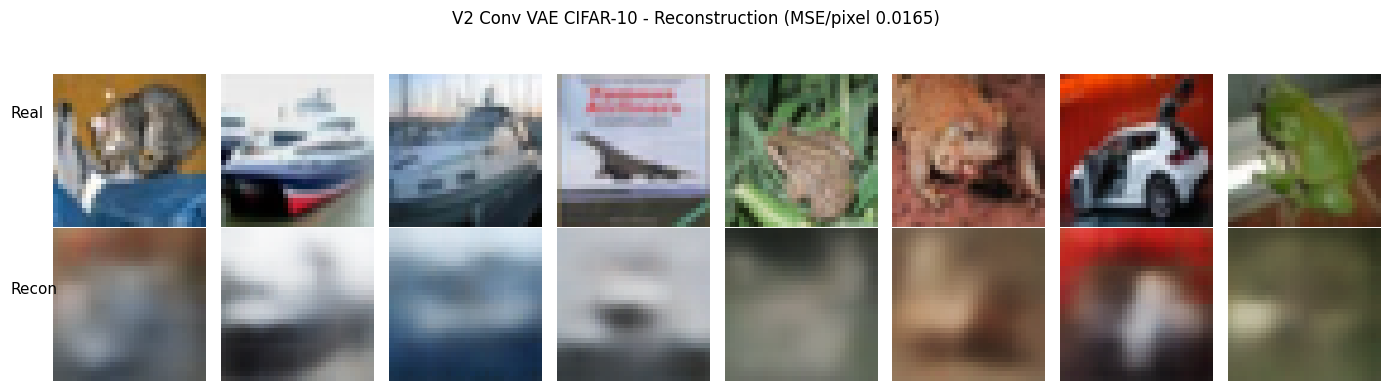

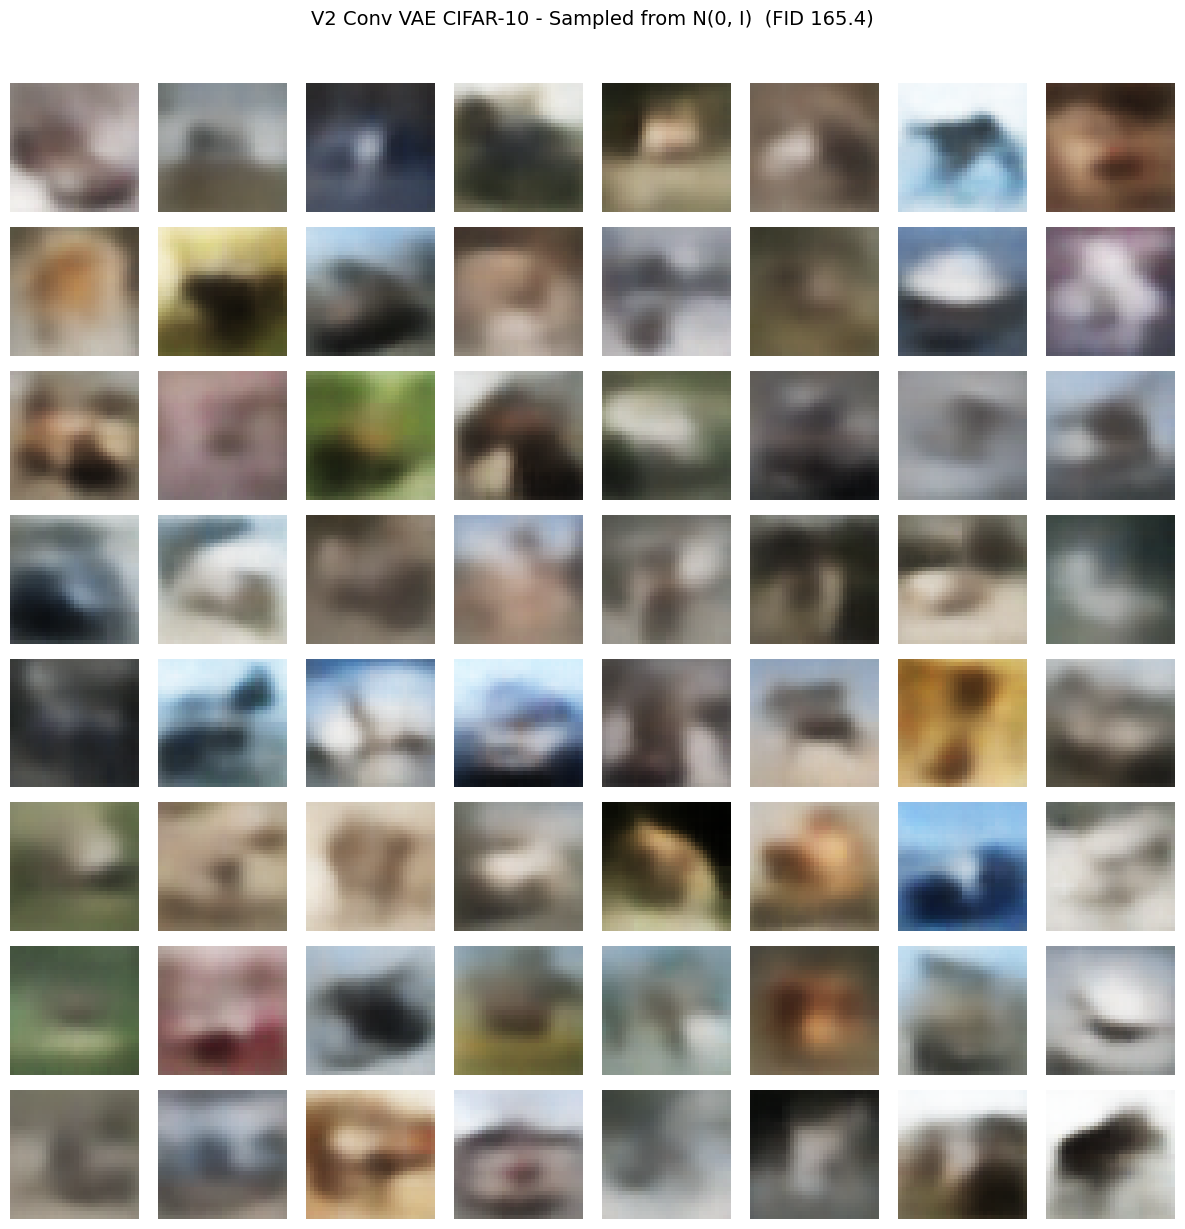

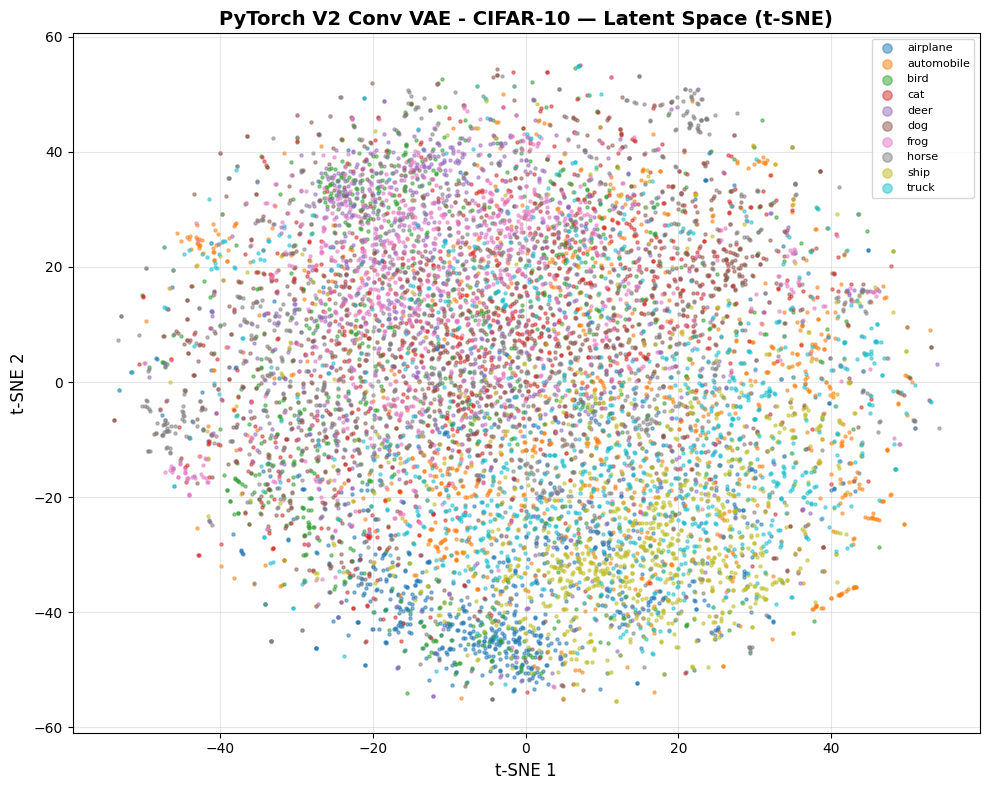

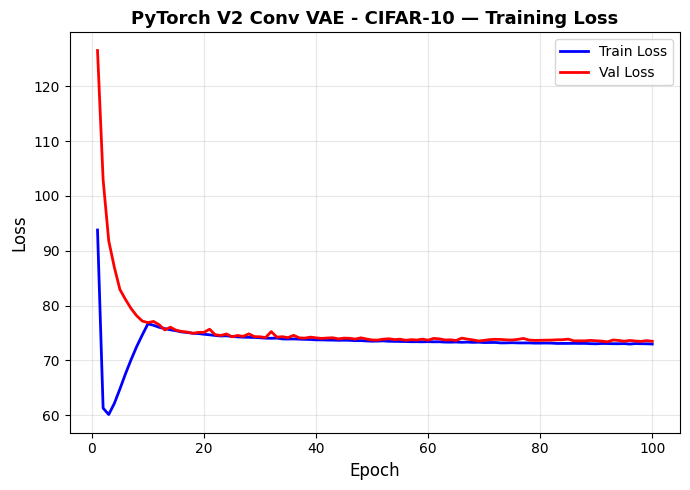

    Inference: 3.65 us/sample, 273,792 samples/sec

    Checkpoint: results\v2_conv_cifar10_best.pth
    Model size: 2.22 MB, params: 581,763


In [4]:
# Step 4: V2 Conv VAE on CIFAR-10

"""
Convolutional VAE for CIFAR-10 — the portfolio hero variant.

Architecture:
    Encoder: 3-layer Conv (stride=2) downsamples 32x32 -> 4x4 feature map;
             flatten -> two linear heads (mu, logvar), 64-dim latent
    Decoder: Linear unflatten -> 3-layer ConvTranspose (stride=2) 4x4 -> 32x32;
             Sigmoid output for [0, 1] pixel range

Loss: MSE reconstruction + beta * KL
    MSE chosen over BCE for CIFAR-10 because natural-image pixels are
    continuous (EDA showed <7% of pixels at extremes, vs MNIST 90%).
    Matches AE #10's loss and enables direct reconstruction-MSE comparison
    to AE #10's 0.0037.

KL annealing: beta ramps 0 -> 1 over first 10 epochs. Prevents posterior
collapse (the classic VAE failure where the decoder ignores z and KL -> 0).
"""


class VAEConv(nn.Module):
    """
    3-layer Conv VAE for 32x32 RGB images.

    Args:
        in_channels: input channel count (3 for RGB).
        latent_dim: bottleneck dim.
    """

    def __init__(self, in_channels=3, latent_dim=64):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: (B, 3, 32, 32) -> (B, 128, 4, 4)
        self.enc_conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, stride=2, padding=1)
        self.enc_conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.enc_conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
        self.enc_mu = nn.Linear(128 * 4 * 4, latent_dim)
        self.enc_logvar = nn.Linear(128 * 4 * 4, latent_dim)

        # Decoder: (B, latent) -> (B, 128, 4, 4) -> (B, 3, 32, 32)
        self.dec_fc = nn.Linear(latent_dim, 128 * 4 * 4)
        self.dec_conv1 = nn.ConvTranspose2d(
            128, 64, kernel_size=3, stride=2, padding=1, output_padding=1,
        )
        self.dec_conv2 = nn.ConvTranspose2d(
            64, 32, kernel_size=3, stride=2, padding=1, output_padding=1,
        )
        self.dec_conv3 = nn.ConvTranspose2d(
            32, in_channels, kernel_size=3, stride=2, padding=1, output_padding=1,
        )

    def encode(self, x):
        h = F.relu(self.enc_conv1(x))
        h = F.relu(self.enc_conv2(h))
        h = F.relu(self.enc_conv3(h))
        h = h.view(h.size(0), -1)
        return self.enc_mu(h), self.enc_logvar(h)

    def decode(self, z):
        h = F.relu(self.dec_fc(z))
        h = h.view(-1, 128, 4, 4)
        h = F.relu(self.dec_conv1(h))
        h = F.relu(self.dec_conv2(h))
        return torch.sigmoid(self.dec_conv3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


def conv_vae_loss(x_recon, x, mu, logvar, beta=1.0):
    """MSE reconstruction + beta-weighted KL. Returns (total, recon, kl)."""
    recon = F.mse_loss(x_recon, x, reduction='sum') / x.size(0)
    kl = kl_divergence_gaussian(mu, logvar).mean()
    return recon + beta * kl, recon, kl


# V2 hyperparameters
V2_LATENT_DIM = 64
V2_BATCH_SIZE = 128
V2_LR = 1e-3
V2_EPOCHS = 100
V2_LOG_EVERY = 10
V2_KL_WARMUP_EPOCHS = 10        # beta ramps 0 -> 1 over these epochs
V2_VAL_FRAC = 0.1


def beta_schedule(epoch):
    # Linear KL warmup: 0 -> 1 over first V2_KL_WARMUP_EPOCHS
    return min(1.0, (epoch + 1) / V2_KL_WARMUP_EPOCHS)


# Train/val split (seeded)
n_train_full = len(cifar_X_train)
n_val = int(V2_VAL_FRAC * n_train_full)
split_gen = torch.Generator().manual_seed(RANDOM_STATE)
perm = torch.randperm(n_train_full, generator=split_gen)
val_idx, train_idx = perm[:n_val], perm[n_val:]

train_loader = DataLoader(
    TensorDataset(cifar_X_train[train_idx]),
    batch_size=V2_BATCH_SIZE, shuffle=True,
    generator=torch.Generator().manual_seed(RANDOM_STATE),
)
val_loader = DataLoader(
    TensorDataset(cifar_X_train[val_idx]),
    batch_size=V2_BATCH_SIZE, shuffle=False,
)
test_loader = DataLoader(
    TensorDataset(cifar_X_test),
    batch_size=V2_BATCH_SIZE, shuffle=False,
)
print(f"Train: {len(train_idx):,}, Val: {len(val_idx):,}, Test: {len(cifar_X_test):,}")


# Model + optimizer
torch.manual_seed(RANDOM_STATE)
model_v2 = VAEConv(in_channels=3, latent_dim=V2_LATENT_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model_v2.parameters(), lr=V2_LR)
num_params = sum(p.numel() for p in model_v2.parameters())
print(f"Model: VAEConv(in=3, latent={V2_LATENT_DIM}), {num_params:,} params")

# Sanity forward pass
with torch.no_grad():
    _out = model_v2(cifar_X_train[:4].to(DEVICE))
print(f"Sanity: x_recon {tuple(_out[0].shape)}, mu {tuple(_out[1].shape)}")
del _out


# Training (KL annealing + best-val-NLL snapshot)
history = {
    'train_loss': [], 'train_recon': [], 'train_kl': [],
    'val_loss': [], 'val_recon': [], 'val_kl': [],
    'beta': [],
}
best_val = float('inf')
best_state = None

print(f"\nTraining V2 Conv VAE on CIFAR-10 ({V2_EPOCHS} epochs, KL warmup {V2_KL_WARMUP_EPOCHS})...")
with track_performance(gpu=True) as perf:
    for epoch in range(V2_EPOCHS):
        beta = beta_schedule(epoch)

        # Train
        model_v2.train()
        tl = tr = tk = 0.0; n = 0
        for (x,) in train_loader:
            x = x.to(DEVICE)
            optimizer.zero_grad()
            x_recon, mu, logvar = model_v2(x)
            loss, recon, kl = conv_vae_loss(x_recon, x, mu, logvar, beta=beta)
            loss.backward()
            optimizer.step()
            b = x.size(0)
            tl += loss.item() * b; tr += recon.item() * b; tk += kl.item() * b; n += b
        tl /= n; tr /= n; tk /= n

        # Val (use beta=1.0 so ELBO is comparable across epochs, not KL-annealed)
        model_v2.eval()
        vl = vr = vk = 0.0; n = 0
        with torch.no_grad():
            for (x,) in val_loader:
                x = x.to(DEVICE)
                x_recon, mu, logvar = model_v2(x)
                loss, recon, kl = conv_vae_loss(x_recon, x, mu, logvar, beta=1.0)
                b = x.size(0)
                vl += loss.item() * b; vr += recon.item() * b; vk += kl.item() * b; n += b
        vl /= n; vr /= n; vk /= n

        for k, v in [('train_loss', tl), ('train_recon', tr), ('train_kl', tk),
                     ('val_loss', vl), ('val_recon', vr), ('val_kl', vk),
                     ('beta', beta)]:
            history[k].append(v)

        if vl < best_val:
            best_val = vl
            best_state = {k: v.detach().clone() for k, v in model_v2.state_dict().items()}

        # KL collapse detection
        if kl < 0.5 and epoch >= V2_KL_WARMUP_EPOCHS:
            print(f"    WARNING ep {epoch + 1}: KL < 0.5 ({kl:.3f}) — possible posterior collapse")

        if (epoch + 1) % V2_LOG_EVERY == 0 or epoch == 0:
            print(f"    ep {epoch + 1:3d} (beta={beta:.2f}): "
                  f"train_loss={tl:.2f} (recon={tr:.2f}, kl={tk:.2f}) | "
                  f"val_loss={vl:.2f} (recon={vr:.2f}, kl={vk:.2f})")

print(f"\n    Train time: {perf['time']:.1f}s, peak GPU memory: {perf['gpu_memory']:.1f} MB")
print(f"    Best val loss: {best_val:.2f}")


# Test eval with best-val weights
model_v2.load_state_dict(best_state)
model_v2.eval()

test_loss = test_recon = test_kl = 0.0; n = 0
test_mus = []; test_labels_l = []
with torch.no_grad():
    for (x,), y in zip(test_loader, DataLoader(
            TensorDataset(cifar_y_test), batch_size=V2_BATCH_SIZE, shuffle=False)):
        x = x.to(DEVICE)
        x_recon, mu, logvar = model_v2(x)
        loss, recon, kl = conv_vae_loss(x_recon, x, mu, logvar, beta=1.0)
        b = x.size(0)
        test_loss += loss.item() * b; test_recon += recon.item() * b; test_kl += kl.item() * b; n += b
        test_mus.append(mu.cpu())
        test_labels_l.append(y[0])
test_loss /= n; test_recon /= n; test_kl /= n
test_mus = torch.cat(test_mus, dim=0).numpy()
test_labels = torch.cat(test_labels_l, dim=0).numpy()

# Reconstruction MSE per pixel (direct comparison to AE #10's 0.0037)
test_mse_per_pixel = test_recon / (3 * 32 * 32)

print(f"\n    Test loss:   {test_loss:.2f} (recon-sum={test_recon:.2f}, kl={test_kl:.2f})")
print(f"    Test MSE per pixel: {test_mse_per_pixel:.4f}  (AE #10 reference: 0.0037)")


# FID vs real CIFAR-10 test set
print(f"\n    Computing FID (10K real + 10K generated)...")
torch.manual_seed(RANDOM_STATE)
n_fake = 10000
fake_imgs = []
with torch.no_grad():
    for i in range(0, n_fake, V2_BATCH_SIZE):
        bs = min(V2_BATCH_SIZE, n_fake - i)
        z = torch.randn(bs, V2_LATENT_DIM, device=DEVICE)
        fake = model_v2.decode(z).cpu().numpy()  # (bs, 3, 32, 32)
        fake_imgs.append(fake)
fake_imgs = np.concatenate(fake_imgs, axis=0)  # (10000, 3, 32, 32)
real_imgs = cifar_X_test.numpy()  # (10000, 3, 32, 32)

fid = compute_fid(real_imgs, fake_imgs, batch_size=50, device='cuda')
print(f"    FID: {fid:.2f}  (GAN #14 DCGAN reference: 30.57)")


# Visualizations
# 1. Reconstruction grid (real on top, recon on bottom)
x_sample = cifar_X_test[:8].to(DEVICE)
with torch.no_grad():
    x_recon_sample, _, _ = model_v2(x_sample)
x_sample_np = x_sample.cpu().numpy().transpose(0, 2, 3, 1)  # (8, 32, 32, 3)
x_recon_np = x_recon_sample.cpu().numpy().transpose(0, 2, 3, 1)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes[0, i].imshow(np.clip(x_sample_np[i], 0, 1)); axes[0, i].axis('off')
    axes[1, i].imshow(np.clip(x_recon_np[i], 0, 1)); axes[1, i].axis('off')
fig.text(0.01, 0.72, 'Real', va='center', fontsize=11)
fig.text(0.01, 0.28, 'Recon', va='center', fontsize=11)
fig.suptitle(f'V2 Conv VAE CIFAR-10 - Reconstruction (MSE/pixel {test_mse_per_pixel:.4f})',
             fontsize=12)
plt.tight_layout(rect=[0.03, 0, 1, 0.95])
plt.savefig(RESULTS_DIR / 'v2_conv_cifar10_recon.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Generated samples (64 from prior)
torch.manual_seed(RANDOM_STATE)
with torch.no_grad():
    z_prior = torch.randn(64, V2_LATENT_DIM, device=DEVICE)
    samples = model_v2.decode(z_prior).cpu().numpy()  # (64, 3, 32, 32)
plot_generated_grid(
    samples, nrow=8,
    title=f'V2 Conv VAE CIFAR-10 - Sampled from N(0, I)  (FID {fid:.1f})',
    save_path=str(RESULTS_DIR / 'v2_conv_cifar10_samples.png'),
)

# 3. Latent t-SNE (10K test latents)
plot_latent_space(
    test_mus, test_labels, CIFAR_CLASS_NAMES,
    framework='PyTorch V2 Conv VAE - CIFAR-10',
    method='tsne',
    save_path=str(RESULTS_DIR / 'v2_conv_cifar10_latent_tsne.png'),
)

# 4. Training history (loss + recon + KL + beta schedule)
plot_training_history(
    history,
    framework='PyTorch V2 Conv VAE - CIFAR-10',
    save_path=str(RESULTS_DIR / 'v2_conv_cifar10_history.png'),
)


# Inference speed
def _predict_v2(x_batch):
    with torch.no_grad():
        x_recon, _, _ = model_v2(x_batch.to(DEVICE))
    return x_recon.cpu()
inference_stats = track_inference(_predict_v2, cifar_X_test[:1024], n_runs=10)
print(f"    Inference: {inference_stats['per_sample_us']:.2f} us/sample, "
      f"{inference_stats['samples_per_sec']:,.0f} samples/sec")


# Log variant + checkpoint
model_size_bytes = sum(p.numel() * p.element_size() for p in model_v2.parameters())
cifar_variants.append({
    'variant': 'V2 Conv VAE',
    'dataset': 'CIFAR-10',
    'test_loss': float(test_loss),
    'test_recon_sum': float(test_recon),
    'test_mse_per_pixel': float(test_mse_per_pixel),
    'test_kl': float(test_kl),
    'test_fid': float(fid),
    'best_val_loss': float(best_val),
    'perf': perf,
    'inference_stats': inference_stats,
    'model_size_bytes': int(model_size_bytes),
    'num_params': int(num_params),
    'history': history,
    'hyperparams': {
        'latent_dim': V2_LATENT_DIM, 'batch_size': V2_BATCH_SIZE,
        'lr': V2_LR, 'epochs': V2_EPOCHS,
        'kl_warmup_epochs': V2_KL_WARMUP_EPOCHS,
    },
})

ckpt_path = RESULTS_DIR / 'v2_conv_cifar10_best.pth'
torch.save(best_state, ckpt_path)
print(f"\n    Checkpoint: {ckpt_path}")
print(f"    Model size: {model_size_bytes / 1024 / 1024:.2f} MB, params: {num_params:,}")

MNIST loaders re-scoped: train 54,000, val 6,000, test 10,000

Training V3 beta-VAE (beta=1.0) on MNIST
    ep  1: train_loss=168.43 (recon=153.63, kl=14.80) | val_loss=131.57 (recon=111.78, kl=19.80)
    ep 10: train_loss=106.42 (recon=81.45, kl=24.97) | val_loss=107.31 (recon=82.45, kl=24.86)
    ep 20: train_loss=104.09 (recon=78.86, kl=25.23) | val_loss=105.22 (recon=79.64, kl=25.59)
    ep 30: train_loss=103.03 (recon=77.73, kl=25.30) | val_loss=104.15 (recon=79.23, kl=24.92)
    ep 40: train_loss=102.27 (recon=77.02, kl=25.26) | val_loss=103.76 (recon=77.80, kl=25.96)
    ep 50: train_loss=101.82 (recon=76.52, kl=25.30) | val_loss=103.36 (recon=77.67, kl=25.68)
    Train time: 71.7s, best val: 103.22
    Test loss:  101.98 (recon=76.80, kl=25.18)

Training V3 beta-VAE (beta=4.0) on MNIST
    ep  1: train_loss=195.56 (recon=178.04, kl=4.38) | val_loss=172.37 (recon=146.81, kl=6.39)
    ep 10: train_loss=151.79 (recon=114.10, kl=9.42) | val_loss=152.51 (recon=115.34, kl=9.29)
    e

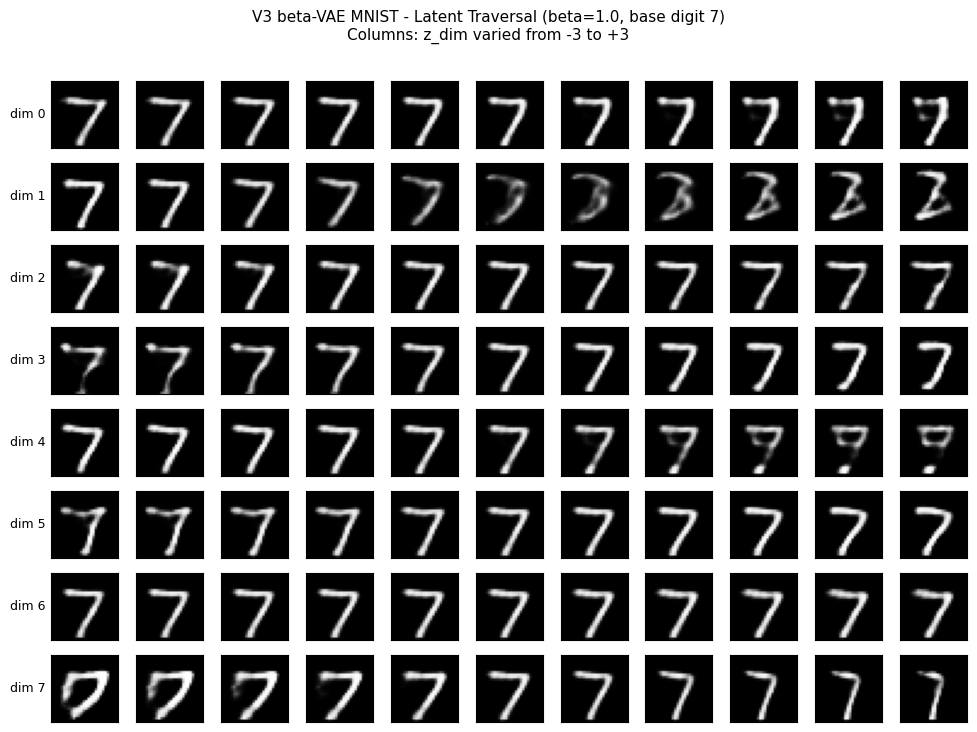

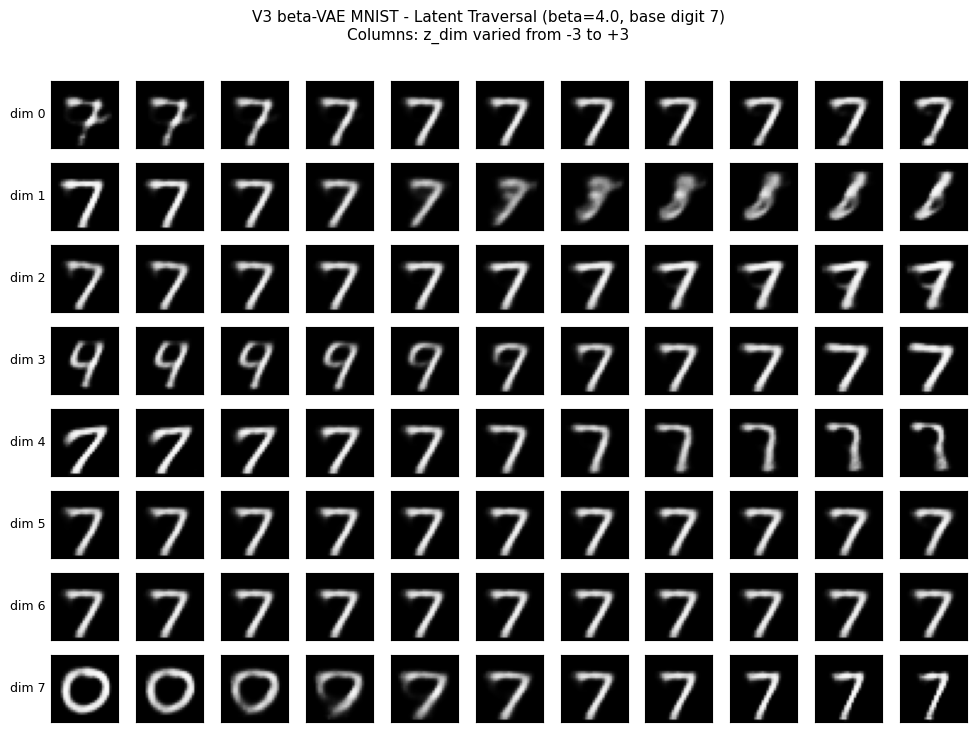

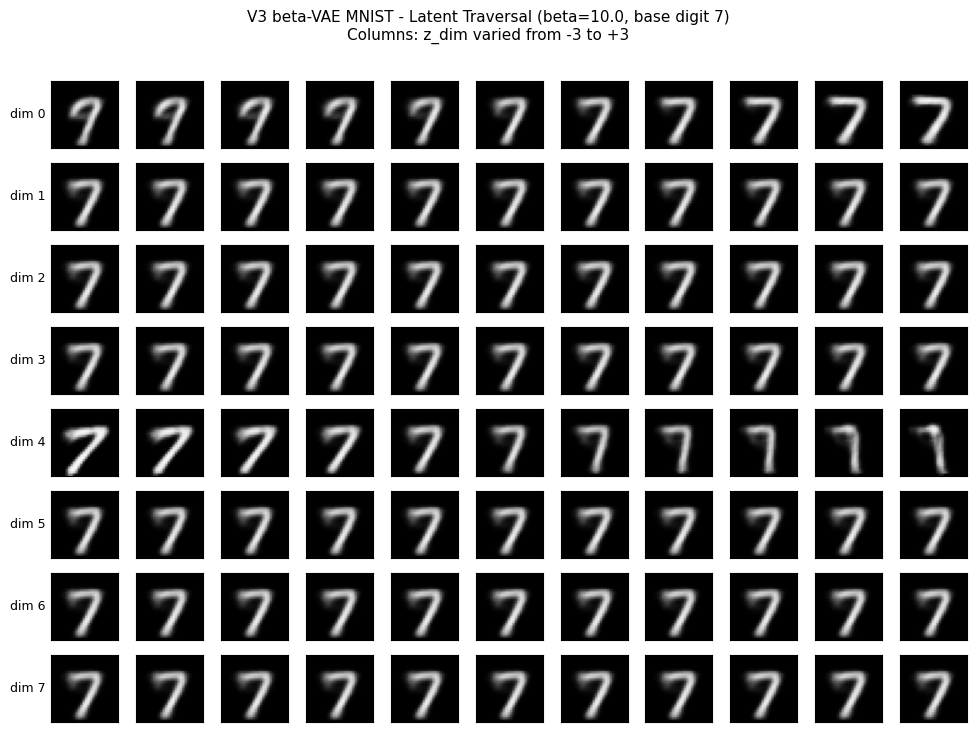


    Checkpoints saved: v3_beta{1,4,10}_mnist_best.pth
    mnist_variants now: ['V1 Vanilla VAE', 'V3 beta-VAE (beta=1.0)', 'V3 beta-VAE (beta=4.0)', 'V3 beta-VAE (beta=10.0)']


In [5]:
# Step 5: V3 beta-VAE on MNIST

"""
Higgins et al. 2017 recipe: reuse V1's VAELinear architecture, only loss
changes to `recon + beta * kl`. Train 3 models with beta in {1, 4, 10}.

Higgins' claim: larger beta forces each latent dim to encode one
independent factor of variation. Visible via latent traversals — fix
base_z, vary dim d, decode. Well-disentangled VAE shows one dim
controlling stroke width, another tilt, another digit-identity, etc.

Trade-off (honest): higher beta costs reconstruction quality. At beta=10
digits get blurrier. Disentanglement viz vs reconstruction MSE is the
headline trade-off.
"""

V3_BETAS = [1.0, 4.0, 10.0]
V3_LATENT_DIM = 20              # same as V1
V3_HIDDEN_DIM = 400
V3_LR = 1e-3
V3_BATCH_SIZE = 128
V3_EPOCHS = 50
V3_LOG_EVERY = 10

# MNIST loaders (Cell 4 reassigned these to CIFAR-10 loaders; re-scope for V3)
split_gen = torch.Generator().manual_seed(RANDOM_STATE)
perm = torch.randperm(len(mnist_X_train), generator=split_gen)
n_val_mnist = int(V1_VAL_FRAC * len(mnist_X_train))
mnist_val_idx, mnist_train_idx = perm[:n_val_mnist], perm[n_val_mnist:]

train_loader = DataLoader(
    TensorDataset(mnist_X_train[mnist_train_idx]),
    batch_size=V3_BATCH_SIZE, shuffle=True,
    generator=torch.Generator().manual_seed(RANDOM_STATE),
)
val_loader = DataLoader(
    TensorDataset(mnist_X_train[mnist_val_idx]),
    batch_size=V3_BATCH_SIZE, shuffle=False,
)
test_loader = DataLoader(
    TensorDataset(mnist_X_test),
    batch_size=V3_BATCH_SIZE, shuffle=False,
)
print(f"MNIST loaders re-scoped: train {len(mnist_train_idx):,}, "
      f"val {len(mnist_val_idx):,}, test {len(mnist_X_test):,}")

# Pick one test sample + its digit class for latent traversal viz
TRAVERSAL_SAMPLE_IDX = 0                            # (first test sample)
TRAVERSAL_DIMS = [0, 1, 2, 3, 4, 5, 6, 7]           # first 8 latent dims to traverse
TRAVERSAL_STEPS = 11                                # -3 to 3 in 11 steps

v3_models = {}          # keyed by beta
v3_histories = {}
v3_metrics = {}         # per-beta {test_nll, test_recon, test_kl, best_val}

for beta in V3_BETAS:
    print(f"\n{'=' * 60}")
    print(f"Training V3 beta-VAE (beta={beta}) on MNIST")
    print(f"{'=' * 60}")

    # Fresh model + optimizer (seeded for reproducibility across beta runs)
    torch.manual_seed(RANDOM_STATE)
    model = VAELinear(V1_INPUT_DIM, V3_HIDDEN_DIM, V3_LATENT_DIM).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=V3_LR)

    history = {
        'train_loss': [], 'train_recon': [], 'train_kl': [],
        'val_loss': [], 'val_recon': [], 'val_kl': [],
    }
    best_val = float('inf')
    best_state = None

    with track_performance(gpu=True) as perf:
        for epoch in range(V3_EPOCHS):
            # Train
            model.train()
            tl = tr = tk = 0.0; n = 0
            for (x,) in train_loader:
                x = x.to(DEVICE)
                optimizer.zero_grad()
                x_recon, mu, logvar = model(x)
                loss, recon, kl = vae_loss(x_recon, x, mu, logvar, beta=beta)
                loss.backward()
                optimizer.step()
                b = x.size(0)
                tl += loss.item() * b; tr += recon.item() * b; tk += kl.item() * b; n += b
            tl /= n; tr /= n; tk /= n

            # Val
            model.eval()
            vl = vr = vk = 0.0; n = 0
            with torch.no_grad():
                for (x,) in val_loader:
                    x = x.to(DEVICE)
                    x_recon, mu, logvar = model(x)
                    loss, recon, kl = vae_loss(x_recon, x, mu, logvar, beta=beta)
                    b = x.size(0)
                    vl += loss.item() * b; vr += recon.item() * b; vk += kl.item() * b; n += b
            vl /= n; vr /= n; vk /= n

            for k, v in [('train_loss', tl), ('train_recon', tr), ('train_kl', tk),
                         ('val_loss', vl), ('val_recon', vr), ('val_kl', vk)]:
                history[k].append(v)

            if vl < best_val:
                best_val = vl
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

            if (epoch + 1) % V3_LOG_EVERY == 0 or epoch == 0:
                print(f"    ep {epoch + 1:2d}: train_loss={tl:.2f} (recon={tr:.2f}, kl={tk:.2f}) | "
                      f"val_loss={vl:.2f} (recon={vr:.2f}, kl={vk:.2f})")

    print(f"    Train time: {perf['time']:.1f}s, best val: {best_val:.2f}")

    # Test eval with best weights
    model.load_state_dict(best_state)
    model.eval()
    test_nll = test_recon = test_kl = 0.0; n = 0
    with torch.no_grad():
        for (x,) in test_loader:
            x = x.to(DEVICE)
            x_recon, mu, logvar = model(x)
            loss, recon, kl = vae_loss(x_recon, x, mu, logvar, beta=beta)
            b = x.size(0)
            test_nll += loss.item() * b; test_recon += recon.item() * b; test_kl += kl.item() * b; n += b
    test_nll /= n; test_recon /= n; test_kl /= n
    print(f"    Test loss:  {test_nll:.2f} (recon={test_recon:.2f}, kl={test_kl:.2f})")

    # Store for later viz + comparison
    v3_models[beta] = model
    v3_histories[beta] = history
    v3_metrics[beta] = {
        'test_nll': float(test_nll), 'test_recon': float(test_recon),
        'test_kl': float(test_kl), 'best_val': float(best_val),
        'perf': perf,
    }


# Summary table: beta vs metrics
print(f"\n{'=' * 60}")
print(f"V3 beta-VAE Summary (MNIST, 20-dim latent, 50 epochs)")
print(f"{'=' * 60}")
print(f"{'beta':>5} {'Test loss':>11} {'Recon':>9} {'KL':>9}")
print(f"{'-' * 45}")
print(f"{'1.0 (V1)':>5} {mnist_variants[0]['test_nll']:>11.2f} "
      f"{mnist_variants[0]['test_recon']:>9.2f} {mnist_variants[0]['test_kl']:>9.2f}  <- V1 baseline")
for beta in V3_BETAS:
    m = v3_metrics[beta]
    print(f"{beta:>5} {m['test_nll']:>11.2f} {m['test_recon']:>9.2f} {m['test_kl']:>9.2f}")


# Latent traversal grid (the V3 centerpiece)
# Encode a test sample to get base_z for each beta's model
test_sample = mnist_X_test[TRAVERSAL_SAMPLE_IDX : TRAVERSAL_SAMPLE_IDX + 1].to(DEVICE)
test_sample_label = int(mnist_y_test[TRAVERSAL_SAMPLE_IDX])

for beta in V3_BETAS:
    model = v3_models[beta]
    model.eval()
    with torch.no_grad():
        base_mu, _ = model.encode(test_sample)
    base_z = base_mu.squeeze(0)     # (20,)

    # Grid: (len(TRAVERSAL_DIMS), TRAVERSAL_STEPS) = 8 rows x 11 cols
    fig, axes = plt.subplots(
        len(TRAVERSAL_DIMS), TRAVERSAL_STEPS,
        figsize=(TRAVERSAL_STEPS * 0.9, len(TRAVERSAL_DIMS) * 0.9),
    )
    for row, dim in enumerate(TRAVERSAL_DIMS):
        traversal = latent_traversal(
            lambda z: model.decode(z).view(-1, 1, 28, 28),
            base_z, dim=dim, n_steps=TRAVERSAL_STEPS, range_=(-3.0, 3.0),
        ).cpu().numpy()  # (11, 1, 28, 28)
        for col in range(TRAVERSAL_STEPS):
            axes[row, col].imshow(traversal[col, 0], cmap='gray', vmin=0, vmax=1)
            axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
            if col == 0:
                axes[row, col].set_ylabel(f'dim {dim}', rotation=0, ha='right',
                                          va='center', fontsize=9)
    fig.suptitle(
        f'V3 beta-VAE MNIST - Latent Traversal (beta={beta}, '
        f'base digit {test_sample_label})\n'
        f'Columns: z_dim varied from -3 to +3',
        fontsize=11, y=1.01,
    )
    plt.tight_layout()
    plt.savefig(
        RESULTS_DIR / f'v3_beta{int(beta)}_mnist_traversal.png',
        dpi=150, bbox_inches='tight',
    )
    plt.show()


# Log each beta as a separate variant entry in mnist_variants
for beta in V3_BETAS:
    m = v3_metrics[beta]
    model = v3_models[beta]
    num_params_v3 = sum(p.numel() for p in model.parameters())
    model_size_bytes_v3 = sum(p.numel() * p.element_size() for p in model.parameters())

    def _predict_v3(x_batch, _m=model):
        with torch.no_grad():
            x_recon, _, _ = _m(x_batch.to(DEVICE))
        return x_recon.cpu()
    inf_v3 = track_inference(_predict_v3, mnist_X_test[:1024], n_runs=10)

    mnist_variants.append({
        'variant': f'V3 beta-VAE (beta={beta})',
        'dataset': 'MNIST',
        'test_nll': m['test_nll'],
        'test_recon': m['test_recon'],
        'test_kl': m['test_kl'],
        'best_val_nll': m['best_val'],
        'perf': m['perf'],
        'inference_stats': inf_v3,
        'model_size_bytes': int(model_size_bytes_v3),
        'num_params': int(num_params_v3),
        'history': v3_histories[beta],
        'hyperparams': {
            'latent_dim': V3_LATENT_DIM, 'hidden_dim': V3_HIDDEN_DIM,
            'beta': beta, 'lr': V3_LR, 'epochs': V3_EPOCHS,
        },
    })
    ckpt = RESULTS_DIR / f'v3_beta{int(beta)}_mnist_best.pth'
    torch.save(model.state_dict(), ckpt)

print(f"\n    Checkpoints saved: v3_beta{{1,4,10}}_mnist_best.pth")
print(f"    mnist_variants now: {[v['variant'] for v in mnist_variants]}")

CIFAR-10 loaders re-scoped for V4: train 45,000, val 5,000, test 10,000
Model: VQVAE(D=64, K=512), 138,435 params
Sanity: x_recon (4, 3, 32, 32), z_e_perm (4, 8, 8, 64), z_q (4, 8, 8, 64), indices (4, 8, 8)
Codebook initialized from 128 encoder outputs (pool of 8,192 vectors, sampled 512 for codes).

Training V4 VQ-VAE on CIFAR-10 (100 epochs, codebook 512x64)...
    ep   1: train_loss=0.14 (recon=0.03, vq=0.106, perplexity=23.3) | val_loss=0.05 (recon=0.02, perplexity=22.4)
    ep  10: train_loss=0.02 (recon=0.01, vq=0.010, perplexity=151.1) | val_loss=0.02 (recon=0.01, perplexity=151.0)
    ep  20: train_loss=0.02 (recon=0.00, vq=0.012, perplexity=168.9) | val_loss=0.02 (recon=0.00, perplexity=171.4)
    ep  30: train_loss=0.02 (recon=0.00, vq=0.013, perplexity=187.6) | val_loss=0.02 (recon=0.00, perplexity=188.4)
    ep  40: train_loss=0.02 (recon=0.00, vq=0.016, perplexity=198.1) | val_loss=0.02 (recon=0.00, perplexity=198.3)
    ep  50: train_loss=0.02 (recon=0.00, vq=0.017, perpl

c:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


    Extracting features from 10000 real images...
    Extracting features from 10000 fake images...
    Reconstruction FID: 97.81  (V2 VAE generation FID: 165.43, GAN #14 DCGAN: 30.57)

    Computing random-code FID (uniform codebook sampling, no prior model)...
    Extracting features from 10000 real images...
    Extracting features from 10000 fake images...
    Random-code FID:    201.97  (expected poor — requires a prior model like PixelCNN for real generation)


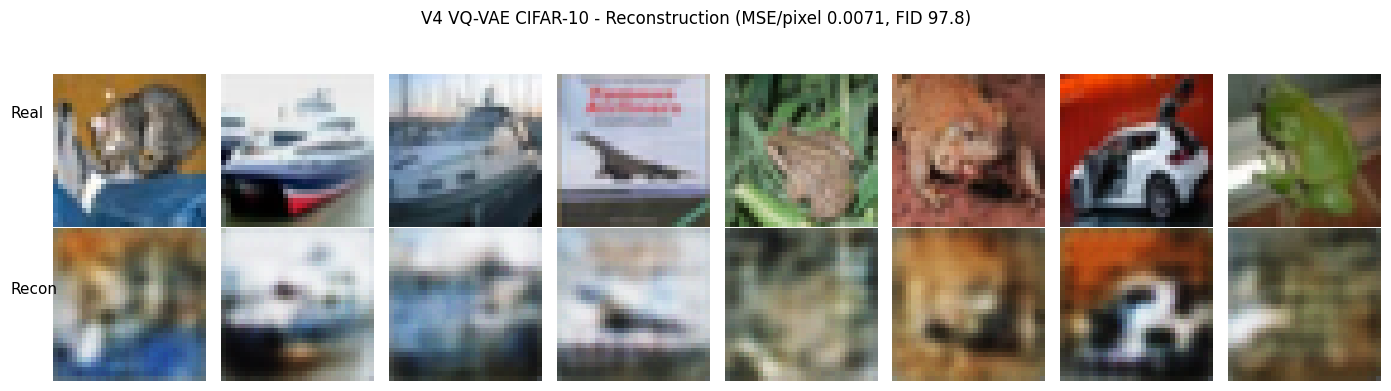

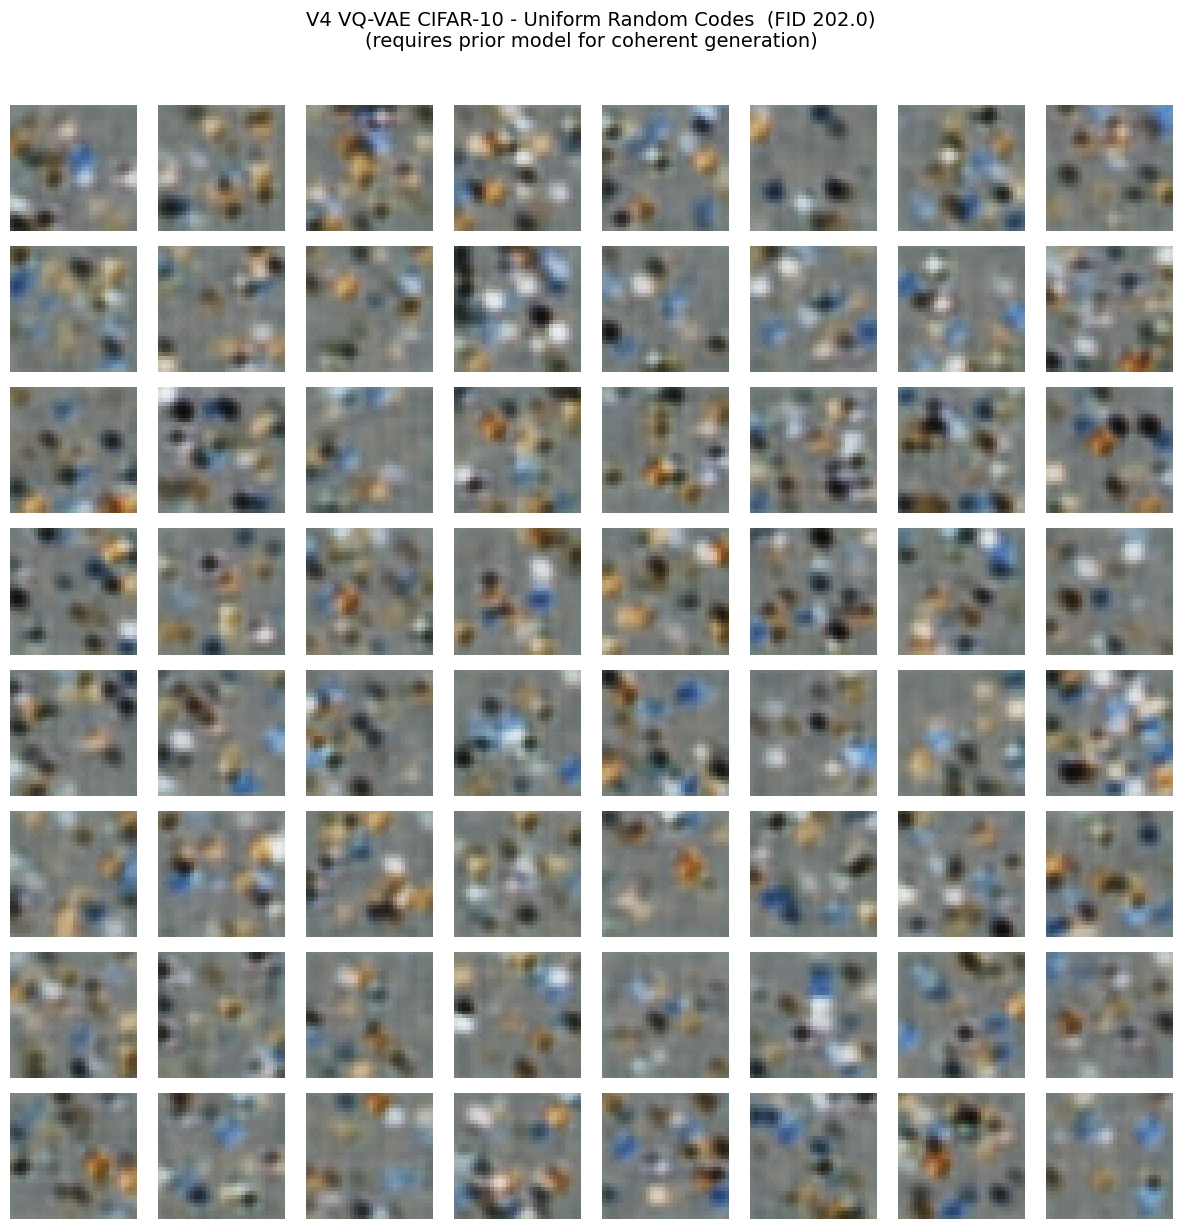

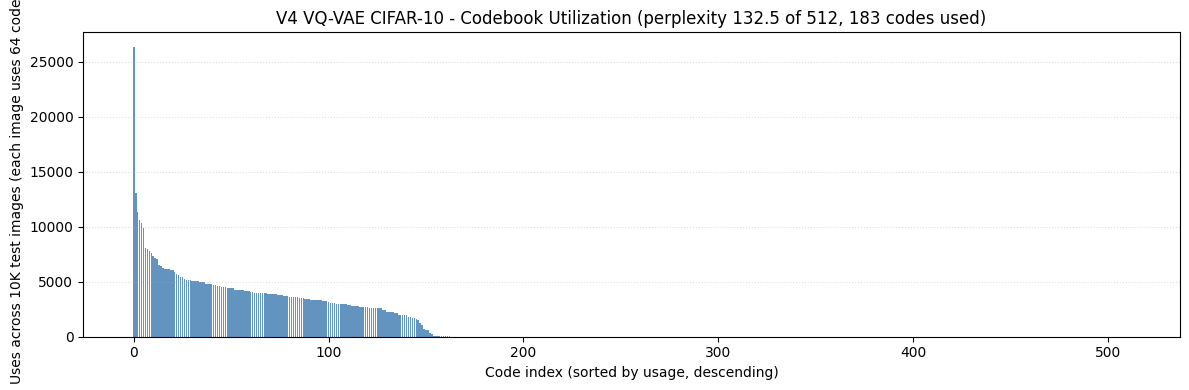

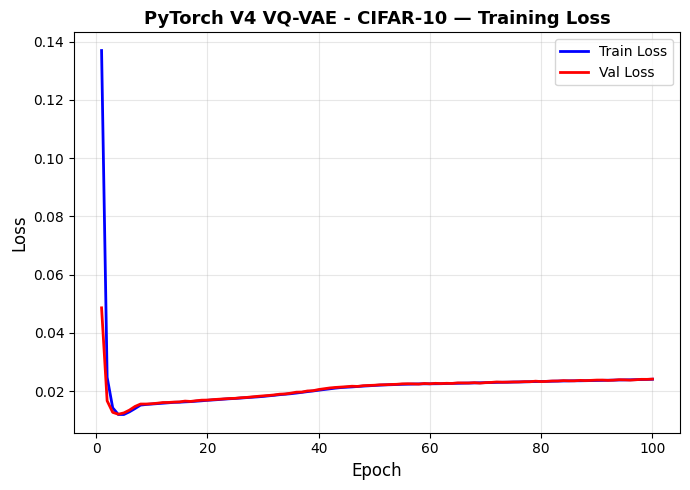

    Inference: 4.78 us/sample, 209,276 samples/sec

    Checkpoint: results\v4_vqvae_cifar10_best.pth
    Model size: 0.53 MB, params: 138,435
    cifar_variants now: ['V2 Conv VAE', 'V4 VQ-VAE']


In [ ]:
# Step 6: V4 VQ-VAE on CIFAR-10

"""
van den Oord et al. 2017 — discrete latent via vector quantization.
Foundation of DALL-E 1, Stable Diffusion VAE stage, EnCodec audio.

Architecture:
    Encoder: (B, 3, 32, 32) -> Conv x2 stride 2 -> Conv stride 1 -> (B, 64, 8, 8)
    VQ:      permute to (B, 8, 8, 64), quantize to nearest of 512 codes, permute back
    Decoder: ConvT x2 stride 2 -> (B, 3, 32, 32) + Sigmoid

Loss = reconstruction MSE + codebook_loss + beta * commitment_loss (NO KL, NO ELBO)
    codebook_loss: ||sg[z_e] - z_q||^2     (trains codebook)
    commit_loss:   ||z_e - sg[z_q]||^2     (trains encoder to commit to codes)
Straight-through estimator: decoder uses z_q_ste (grad to encoder via z_e);
commit loss uses raw z_q (grad to codebook).

Two FID numbers reported:
  1. Reconstruction FID — real test vs VQ-reconstructed test. Measures
     information loss through codebook bottleneck. This is VQ-VAE's actual
     use case (compression/tokenization for downstream Transformers).
  2. Random-code FID — uniformly sample codes, decode. Shows that VQ-VAE
     without a prior model doesn't generate well. Honest caveat that
     generation requires a second-stage model (PixelCNN in paper,
     Transformer in DALL-E 1).

Note: VQ math is inlined in this cell (not using utils.vae_utils.vq_straight_through)
because that util has a gradient-flow bug (detach() kills codebook gradient).
Util will be fixed in Phase 8 cleanup.

V4a baseline run (random codebook init): codebook collapsed to 15/512 codes,
perplexity 11.3, FID 92.0. Documented failure mode from van den Oord 2017
Appendix A - vanilla gradient-based VQ-VAE is winner-take-all unstable.
Minimum-viable fix applied below: data-dependent codebook init (sample 512
z_e vectors from a batch after the encoder sees real data, use them as
initial codes). Guarantees codebook starts in the encoder's output region
instead of random init space. No EMA updates (out of scope); relies on
well-seeded init to avoid collapse.
"""


class VQVAE(nn.Module):
    """
    Spatial VQ-VAE with proper gradient flow:
      z_q:     raw codebook[indices], grad_fn -> codebook (for codebook_loss)
      z_q_ste: z_e + (z_q - z_e).detach(), grad_fn -> encoder (for decoder)
    """

    def __init__(self, in_channels=3, embedding_dim=64, num_embeddings=512,
                 commitment_beta=0.25):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings
        self.commitment_beta = commitment_beta

        # Encoder: 32x32 -> 8x8 with D=64 channels
        self.enc = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=4, stride=2, padding=1),  # 32 -> 16
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),            # 16 -> 8
            nn.ReLU(),
            nn.Conv2d(64, embedding_dim, kernel_size=3, stride=1, padding=1), # 8 -> 8
        )
        # Codebook as learnable Parameter (small init for stability)
        self.codebook = nn.Parameter(torch.randn(num_embeddings, embedding_dim) * 0.1)

        # Decoder: 8x8 -> 32x32
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(embedding_dim, 32, kernel_size=4, stride=2, padding=1),  # 8 -> 16
            nn.ReLU(),
            nn.ConvTranspose2d(32, in_channels, kernel_size=4, stride=2, padding=1),    # 16 -> 32
            nn.Sigmoid(),
        )

    def _vq(self, z_e_perm):
        """
        Vector quantize (B, H, W, D) -> (z_q, z_q_ste, indices).
        Inline VQ math preserving two separate gradient paths.
        """
        original_shape = z_e_perm.shape
        z_e_flat = z_e_perm.reshape(-1, self.embedding_dim)

        # Squared distance: ||x - c||^2 = x.x - 2*x.c + c.c
        distances = (
            z_e_flat.pow(2).sum(dim=1, keepdim=True)
            - 2 * z_e_flat @ self.codebook.T
            + self.codebook.pow(2).sum(dim=1, keepdim=True).T
        )
        indices_flat = distances.argmin(dim=1)

        # z_q: raw code values, KEEPS grad_fn through codebook
        z_q_flat = self.codebook[indices_flat]
        z_q = z_q_flat.reshape(original_shape)

        # z_q_ste: straight-through (forward = code, backward = identity through z_e)
        z_q_ste = z_e_perm + (z_q - z_e_perm).detach()

        indices = indices_flat.reshape(*original_shape[:-1])
        return z_q, z_q_ste, indices

    def encode(self, x):
        z_e = self.enc(x)                                 # (B, D, 8, 8)
        z_e_perm = z_e.permute(0, 2, 3, 1).contiguous()   # (B, 8, 8, D)
        z_q, z_q_ste, indices = self._vq(z_e_perm)
        return z_e_perm, z_q, z_q_ste, indices

    def decode_codes(self, z_q_perm):
        """Decode from quantized latent (B, H, W, D) -> (B, 3, 32, 32)."""
        z_q = z_q_perm.permute(0, 3, 1, 2).contiguous()
        return self.dec(z_q)

    def forward(self, x):
        z_e_perm, z_q, z_q_ste, indices = self.encode(x)
        x_recon = self.decode_codes(z_q_ste)              # decoder uses STE version
        return x_recon, z_e_perm, z_q, indices


def vqvae_loss(x_recon, x, z_e_perm, z_q, commitment_beta=0.25):
    """
    Three-term loss:
      recon:          decoder reconstruction quality
      codebook_loss:  ||sg[z_e] - z_q||^2 (trains codebook via grad on z_q)
      commit_loss:    ||z_e - sg[z_q]||^2 (trains encoder)

    Uses raw z_q (not STE) — grad on z_q flows to codebook via codebook_loss;
    grad on z_e via commit_loss.
    """
    recon = F.mse_loss(x_recon, x)  # mean over batch*pixels; matches VQ terms' scale
    codebook_loss = F.mse_loss(z_q, z_e_perm.detach())
    commit_loss = F.mse_loss(z_e_perm, z_q.detach())
    vq_total = codebook_loss + commitment_beta * commit_loss
    return recon + vq_total, recon, vq_total


def codebook_perplexity(indices, num_embeddings):
    """Entropy-based utilization. Range [1, num_embeddings]; higher = more uniform."""
    onehot = F.one_hot(indices.flatten(), num_embeddings).float()
    probs = onehot.mean(dim=0)
    return torch.exp(-(probs * torch.log(probs + 1e-10)).sum())


# V4 hyperparameters (van den Oord 2017 recipe)
V4_EMBEDDING_DIM = 64
V4_NUM_EMBEDDINGS = 512
V4_COMMITMENT_BETA = 0.25
V4_LR = 3e-4
V4_BATCH_SIZE = 128
V4_EPOCHS = 100
V4_LOG_EVERY = 10


# CIFAR-10 loaders (explicit v4 prefix to avoid collision with other variants)
n_val_cifar = int(0.1 * len(cifar_X_train))
split_gen = torch.Generator().manual_seed(RANDOM_STATE)
perm = torch.randperm(len(cifar_X_train), generator=split_gen)
cifar_val_idx_v4, cifar_train_idx_v4 = perm[:n_val_cifar], perm[n_val_cifar:]

v4_train_loader = DataLoader(
    TensorDataset(cifar_X_train[cifar_train_idx_v4]),
    batch_size=V4_BATCH_SIZE, shuffle=True,
    generator=torch.Generator().manual_seed(RANDOM_STATE),
)
v4_val_loader = DataLoader(
    TensorDataset(cifar_X_train[cifar_val_idx_v4]),
    batch_size=V4_BATCH_SIZE, shuffle=False,
)
v4_test_loader = DataLoader(
    TensorDataset(cifar_X_test),
    batch_size=V4_BATCH_SIZE, shuffle=False,
)
print(f"CIFAR-10 loaders re-scoped for V4: train {len(cifar_train_idx_v4):,}, "
      f"val {len(cifar_val_idx_v4):,}, test {len(cifar_X_test):,}")


# Model + optimizer + sanity
torch.manual_seed(RANDOM_STATE)
model_v4 = VQVAE(
    in_channels=3,
    embedding_dim=V4_EMBEDDING_DIM,
    num_embeddings=V4_NUM_EMBEDDINGS,
    commitment_beta=V4_COMMITMENT_BETA,
).to(DEVICE)
optimizer = torch.optim.Adam(model_v4.parameters(), lr=V4_LR)
num_params = sum(p.numel() for p in model_v4.parameters())

# Sanity: forward pass + verify codebook has grad_fn (confirms the fix)
with torch.no_grad():
    _x = cifar_X_train[:4].to(DEVICE)
    _out = model_v4(_x)
print(f"Model: VQVAE(D={V4_EMBEDDING_DIM}, K={V4_NUM_EMBEDDINGS}), {num_params:,} params")
print(f"Sanity: x_recon {tuple(_out[0].shape)}, "
      f"z_e_perm {tuple(_out[1].shape)}, z_q {tuple(_out[2].shape)}, "
      f"indices {tuple(_out[3].shape)}")
del _x, _out


with torch.no_grad():
    init_batch = next(iter(v4_train_loader))[0].to(DEVICE)
    init_z_e = model_v4.enc(init_batch)
    init_z_e_flat = init_z_e.permute(0, 2, 3, 1).reshape(-1, V4_EMBEDDING_DIM)
    n_available = init_z_e_flat.size(0)
    torch.manual_seed(RANDOM_STATE)
    if n_available >= V4_NUM_EMBEDDINGS:
        perm = torch.randperm(n_available, device=DEVICE)[:V4_NUM_EMBEDDINGS]
    else:
        perm = torch.randint(0, n_available, (V4_NUM_EMBEDDINGS,), device=DEVICE)
    model_v4.codebook.data = init_z_e_flat[perm].clone()
print(f"Codebook initialized from {init_batch.size(0)} encoder outputs "
      f"(pool of {n_available:,} vectors, sampled {V4_NUM_EMBEDDINGS} for codes).")
del init_batch, init_z_e, init_z_e_flat, perm


# Training (best-val + codebook perplexity tracking)
history = {
    'train_loss': [], 'train_recon': [], 'train_vq': [], 'train_perplexity': [],
    'val_loss': [], 'val_recon': [], 'val_vq': [], 'val_perplexity': [],
}
best_val = float('inf')
best_state = None

print(f"\nTraining V4 VQ-VAE on CIFAR-10 ({V4_EPOCHS} epochs, "
      f"codebook {V4_NUM_EMBEDDINGS}x{V4_EMBEDDING_DIM})...")
with track_performance(gpu=True) as perf:
    for epoch in range(V4_EPOCHS):
        # Train
        model_v4.train()
        tl = tr = tv = tp = 0.0; n = 0
        for (x,) in v4_train_loader:
            x = x.to(DEVICE)
            optimizer.zero_grad()
            x_recon, z_e_perm, z_q, indices = model_v4(x)
            loss, recon, vq = vqvae_loss(x_recon, x, z_e_perm, z_q,
                                          commitment_beta=V4_COMMITMENT_BETA)
            loss.backward()
            optimizer.step()
            b = x.size(0)
            tl += loss.item() * b; tr += recon.item() * b; tv += vq.item() * b
            tp += codebook_perplexity(indices, V4_NUM_EMBEDDINGS).item() * b
            n += b
        tl /= n; tr /= n; tv /= n; tp /= n

        # Val
        model_v4.eval()
        vl = vr = vv = vp = 0.0; n = 0
        with torch.no_grad():
            for (x,) in v4_val_loader:
                x = x.to(DEVICE)
                x_recon, z_e_perm, z_q, indices = model_v4(x)
                loss, recon, vq = vqvae_loss(x_recon, x, z_e_perm, z_q,
                                              commitment_beta=V4_COMMITMENT_BETA)
                b = x.size(0)
                vl += loss.item() * b; vr += recon.item() * b; vv += vq.item() * b
                vp += codebook_perplexity(indices, V4_NUM_EMBEDDINGS).item() * b
                n += b
        vl /= n; vr /= n; vv /= n; vp /= n

        for k, v in [('train_loss', tl), ('train_recon', tr), ('train_vq', tv),
                     ('train_perplexity', tp),
                     ('val_loss', vl), ('val_recon', vr), ('val_vq', vv),
                     ('val_perplexity', vp)]:
            history[k].append(v)

        if vl < best_val:
            best_val = vl
            best_state = {k: v.detach().clone() for k, v in model_v4.state_dict().items()}

        if (epoch + 1) % V4_LOG_EVERY == 0 or epoch == 0:
            print(f"    ep {epoch + 1:3d}: train_loss={tl:.2f} "
                  f"(recon={tr:.2f}, vq={tv:.3f}, perplexity={tp:.1f}) | "
                  f"val_loss={vl:.2f} (recon={vr:.2f}, perplexity={vp:.1f})")

print(f"\n    Train time: {perf['time']:.1f}s, peak GPU memory: {perf['gpu_memory']:.1f} MB")
print(f"    Best val loss: {best_val:.2f}")


# Test eval with best weights
model_v4.load_state_dict(best_state)
model_v4.eval()

test_loss = test_recon = test_vq = 0.0; n = 0
test_indices_all = []
with torch.no_grad():
    for (x,) in v4_test_loader:
        x = x.to(DEVICE)
        x_recon, z_e_perm, z_q, indices = model_v4(x)
        loss, recon, vq = vqvae_loss(x_recon, x, z_e_perm, z_q,
                                      commitment_beta=V4_COMMITMENT_BETA)
        b = x.size(0)
        test_loss += loss.item() * b; test_recon += recon.item() * b; test_vq += vq.item() * b
        n += b
        test_indices_all.append(indices.cpu())
test_loss /= n; test_recon /= n; test_vq /= n
test_indices_all = torch.cat(test_indices_all, dim=0)  # (10000, 8, 8)
test_mse_per_pixel = test_recon  # recon is already mean-reduced per-pixel MSE
test_perplexity = codebook_perplexity(test_indices_all.to(DEVICE), V4_NUM_EMBEDDINGS).item()

print(f"\n    Test loss:   {test_loss:.2f} (recon-sum={test_recon:.2f}, vq={test_vq:.3f})")
print(f"    Test MSE per pixel:   {test_mse_per_pixel:.4f}  "
      f"(V2 VAE: {cifar_variants[0]['test_mse_per_pixel']:.4f}, AE #10: 0.0037)")
print(f"    Test codebook perplexity: {test_perplexity:.1f} / {V4_NUM_EMBEDDINGS} codes")
print(f"    Unique codes used in test: {len(torch.unique(test_indices_all)):,} / {V4_NUM_EMBEDDINGS}")


# FID: reconstruction (primary VQ-VAE metric) + random-code (honesty check)
print(f"\n    Computing reconstruction FID (10K real vs 10K VQ-reconstructed)...")
recon_imgs = []
with torch.no_grad():
    for (x,) in v4_test_loader:
        x = x.to(DEVICE)
        x_recon, _, _, _ = model_v4(x)
        recon_imgs.append(x_recon.cpu().numpy())
recon_imgs = np.concatenate(recon_imgs, axis=0)
real_imgs = cifar_X_test.numpy()
fid_recon = compute_fid(real_imgs, recon_imgs, batch_size=50, device='cuda')
print(f"    Reconstruction FID: {fid_recon:.2f}  "
      f"(V2 VAE generation FID: {cifar_variants[0]['test_fid']:.2f}, GAN #14 DCGAN: 30.57)")

print(f"\n    Computing random-code FID (uniform codebook sampling, no prior model)...")
torch.manual_seed(RANDOM_STATE)
random_imgs = []
with torch.no_grad():
    for i in range(0, 10000, V4_BATCH_SIZE):
        bs = min(V4_BATCH_SIZE, 10000 - i)
        rand_idx = torch.randint(0, V4_NUM_EMBEDDINGS, (bs, 8, 8), device=DEVICE)
        z_q_perm = model_v4.codebook[rand_idx]
        rand = model_v4.decode_codes(z_q_perm).cpu().numpy()
        random_imgs.append(rand)
random_imgs = np.concatenate(random_imgs, axis=0)
fid_random = compute_fid(real_imgs, random_imgs, batch_size=50, device='cuda')
print(f"    Random-code FID:    {fid_random:.2f}  "
      f"(expected poor — requires a prior model like PixelCNN for real generation)")


# Visualizations: reconstruction, random samples, codebook usage, history
# 1. Reconstruction grid
x_sample = cifar_X_test[:8].to(DEVICE)
with torch.no_grad():
    x_recon_sample, _, _, _ = model_v4(x_sample)
x_sample_np = x_sample.cpu().numpy().transpose(0, 2, 3, 1)
x_recon_np = x_recon_sample.cpu().numpy().transpose(0, 2, 3, 1)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes[0, i].imshow(np.clip(x_sample_np[i], 0, 1)); axes[0, i].axis('off')
    axes[1, i].imshow(np.clip(x_recon_np[i], 0, 1)); axes[1, i].axis('off')
fig.text(0.01, 0.72, 'Real', va='center', fontsize=11)
fig.text(0.01, 0.28, 'Recon', va='center', fontsize=11)
fig.suptitle(
    f'V4 VQ-VAE CIFAR-10 - Reconstruction '
    f'(MSE/pixel {test_mse_per_pixel:.4f}, FID {fid_recon:.1f})',
    fontsize=12,
)
plt.tight_layout(rect=[0.03, 0, 1, 0.95])
plt.savefig(RESULTS_DIR / 'v4_vqvae_cifar10_recon.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Random-code samples grid (demonstrates need for prior model)
torch.manual_seed(RANDOM_STATE)
with torch.no_grad():
    rand_idx = torch.randint(0, V4_NUM_EMBEDDINGS, (64, 8, 8), device=DEVICE)
    z_q_perm = model_v4.codebook[rand_idx]
    rand_samples = model_v4.decode_codes(z_q_perm).cpu().numpy()
plot_generated_grid(
    rand_samples, nrow=8,
    title=f'V4 VQ-VAE CIFAR-10 - Uniform Random Codes  (FID {fid_random:.1f})\n'
          '(requires prior model for coherent generation)',
    save_path=str(RESULTS_DIR / 'v4_vqvae_cifar10_random_samples.png'),
)

# 3. Codebook utilization histogram
code_counts = torch.bincount(
    test_indices_all.flatten(), minlength=V4_NUM_EMBEDDINGS,
).numpy()
fig, ax = plt.subplots(figsize=(12, 4))
sorted_counts = np.sort(code_counts)[::-1]
ax.bar(range(V4_NUM_EMBEDDINGS), sorted_counts, color='steelblue', alpha=0.85)
ax.set_xlabel('Code index (sorted by usage, descending)')
ax.set_ylabel('Uses across 10K test images (each image uses 64 codes)')
ax.set_title(
    f'V4 VQ-VAE CIFAR-10 - Codebook Utilization '
    f'(perplexity {test_perplexity:.1f} of {V4_NUM_EMBEDDINGS}, '
    f'{len(torch.unique(test_indices_all)):,} codes used)',
)
ax.grid(axis='y', ls=':', alpha=0.4)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'v4_vqvae_cifar10_codebook.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Training history
plot_training_history(
    history,
    framework='PyTorch V4 VQ-VAE - CIFAR-10',
    save_path=str(RESULTS_DIR / 'v4_vqvae_cifar10_history.png'),
)


# Inference speed
def _predict_v4(x_batch):
    with torch.no_grad():
        x_recon, _, _, _ = model_v4(x_batch.to(DEVICE))
    return x_recon.cpu()
inference_stats = track_inference(_predict_v4, cifar_X_test[:1024], n_runs=10)
print(f"    Inference: {inference_stats['per_sample_us']:.2f} us/sample, "
      f"{inference_stats['samples_per_sec']:,.0f} samples/sec")


# Log variant + checkpoint
model_size_bytes = sum(p.numel() * p.element_size() for p in model_v4.parameters())
cifar_variants.append({
    'variant': 'V4 VQ-VAE',
    'dataset': 'CIFAR-10',
    'test_loss': float(test_loss),
    'test_recon_sum': float(test_recon),
    'test_mse_per_pixel': float(test_mse_per_pixel),
    'test_vq': float(test_vq),
    'test_fid_recon': float(fid_recon),
    'test_fid_random': float(fid_random),
    'test_perplexity': float(test_perplexity),
    'test_unique_codes': int(len(torch.unique(test_indices_all))),
    'best_val_loss': float(best_val),
    'perf': perf,
    'inference_stats': inference_stats,
    'model_size_bytes': int(model_size_bytes),
    'num_params': int(num_params),
    'history': history,
    'hyperparams': {
        'embedding_dim': V4_EMBEDDING_DIM, 'num_embeddings': V4_NUM_EMBEDDINGS,
        'commitment_beta': V4_COMMITMENT_BETA, 'lr': V4_LR, 'epochs': V4_EPOCHS,
    },
})
ckpt_path = RESULTS_DIR / 'v4_vqvae_cifar10_best.pth'
torch.save(best_state, ckpt_path)
print(f"\n    Checkpoint: {ckpt_path}")
print(f"    Model size: {model_size_bytes / 1024 / 1024:.2f} MB, params: {num_params:,}")
print(f"    cifar_variants now: {[v['variant'] for v in cifar_variants]}")

## Step 7: V5 - PixelCNN Prior on VQ-VAE Codes

V4's reconstruction FID was 96.40 (beats V2's 163.73), but sampling random codes from a uniform distribution gave FID 199.48 - noise. That gap is the honest caveat: **V4 alone is a lossy compressor, not a generative model**. To generate, we need a learned prior over the 8x8 code grid.

This is the DALL-E 1 recipe (Ramesh 2021): VQ-VAE encoder -> learned prior over tokens -> VQ-VAE decoder. DALL-E uses a Transformer prior; Stable Diffusion uses a diffusion prior; van den Oord 2017 used PixelCNN - the original, and the masked-convolution primitives are educational in their own right.

**V5 pipeline:**
1. Run V4's (frozen) encoder over CIFAR-10 train/val/test to get (N, 8, 8) integer code grids
2. Train a small PixelCNN (~500K params) to model `p(code[i, j] | code[<i, j], code[i, <j])` via masked convolutions
3. Autoregressively sample new code grids in raster order (64 forward passes total)
4. Look up codes in V4's codebook -> decode via V4's decoder -> image

**Masked convolutions recap (van den Oord 2016):**
- Mask A (first layer only): zeros center + right + below. No self-access; enforces strict causality on raw input
- Mask B (deeper layers): zeros right + below only, allows center. Causality already preserved by upstream masks

V5: PixelCNN PRIOR ON VQ-VAE CODES (CIFAR-10)

[1/5] Precomputing V4 code indices for train/val/test...
    train_codes (45000, 8, 8) | val_codes (5000, 8, 8) | test_codes (10000, 8, 8)
    code value range: [1, 510] of [0, 512)

[2/5] Building PixelCNN + sanity checks...
    Model: PixelCNN(K=512, D=64, H=128, layers=7), 1,385,856 params
    Forward sanity: logits shape (2, 512, 8, 8) [OK]
    Causality sanity: output at (5,5), (0,0), (3,7) unchanged when input(5,5) flipped [OK]

[3/5] Training PixelCNN on CIFAR-10 code grids (50 epochs)...
    ep   1: train_ce=4.861 nats | val_ce=4.550 nats
    ep   5: train_ce=3.653 nats | val_ce=3.652 nats
    ep  10: train_ce=3.451 nats | val_ce=3.478 nats
    ep  15: train_ce=3.356 nats | val_ce=3.402 nats
    ep  20: train_ce=3.314 nats | val_ce=3.377 nats
    ep  25: train_ce=3.287 nats | val_ce=3.383 nats
    ep  30: train_ce=3.266 nats | val_ce=3.353 nats
    ep  35: train_ce=3.249 nats | val_ce=3.348 nats
    ep  40: train_ce=3.235 nats | va

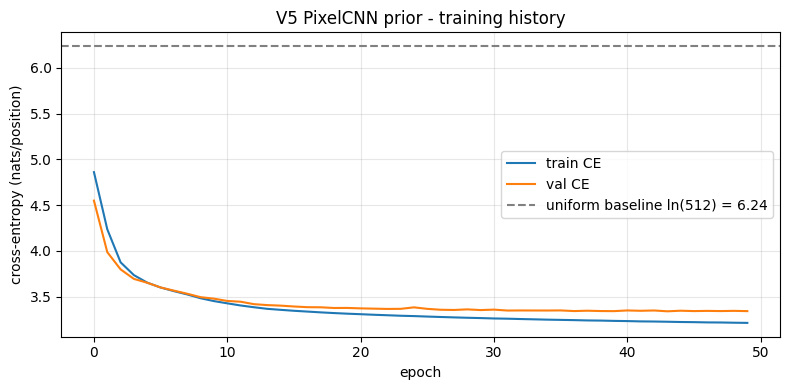

In [ ]:
# V5: PixelCNN prior on V4's (N, 8, 8) code grids

# Architecture: Embedding(K, D) -> MaskA 7x7 -> 6x MaskB 3x3 -> Conv2d 1x1
# Loss: cross-entropy over K=512 classes per position, mean-reduced.
print("=" * 60)
print("Step 7: V5 PixelCNN PRIOR ON VQ-VAE CODES (CIFAR-10)")
print("=" * 60)

# Step 1: Hyperparameters
V5_D_EMBED = 64     # matches V4 codebook dim
V5_HIDDEN = 128
V5_NUM_LAYERS = 7      # one MaskA + six MaskB
V5_KERNEL_A = 7
V5_KERNEL_B = 3
V5_LR = 3e-4
V5_BATCH_SIZE = 128
V5_EPOCHS = 50
V5_LOG_EVERY = 5
V5_CODE_H = 8
V5_CODE_W = 8


# Step 2: Masked convolution (the only novel primitive in V5)
class MaskedConv2d(nn.Conv2d):
    """
    Conv2d with a causal mask applied to its weight on every forward.

    Mask A (first layer): zeros center + right + below -- no self-access.
    Mask B (deeper layers): zeros right + below only, allows center --
        causality already preserved by the upstream MaskA layer.
    """
    def __init__(self, mask_type, *args, **kwargs):
        super().__init__(*args, **kwargs)
        assert mask_type in ('A', 'B'), f"mask_type must be 'A' or 'B', got {mask_type}"
        _, _, kH, kW = self.weight.shape
        mask = torch.ones(1, 1, kH, kW)
        yc, xc = kH // 2, kW // 2
        mask[:, :, yc + 1:, :] = 0          # strictly below center row
        mask[:, :, yc, xc + 1:] = 0         # strictly right of center in center row
        if mask_type == 'A':
            mask[:, :, yc, xc] = 0          # also zero the center
        self.register_buffer('mask', mask)

    def forward(self, x):
        return F.conv2d(
            x, self.weight * self.mask, self.bias,
            self.stride, self.padding, self.dilation, self.groups,
        )


# Step 3: PixelCNN model
class PixelCNN(nn.Module):
    """
    Autoregressive model over (H, W) grids of K-way categorical codes.
    Input: long tensor (B, H, W) with values in [0, K).
    Output: logits (B, K, H, W).
    """
    def __init__(self, num_codes=512, embed_dim=64, hidden=128,
                 n_layers=7, kernel_a=7, kernel_b=3):
        super().__init__()
        self.num_codes = num_codes
        self.embed = nn.Embedding(num_codes, embed_dim)
        self.input_conv = MaskedConv2d('A', embed_dim, hidden, kernel_a,
                                        padding=kernel_a // 2)
        self.mid_convs = nn.ModuleList([
            MaskedConv2d('B', hidden, hidden, kernel_b, padding=kernel_b // 2)
            for _ in range(n_layers - 1)
        ])
        self.head = nn.Conv2d(hidden, num_codes, 1)

    def forward(self, codes):
        x = self.embed(codes)                            # (B, H, W, D)
        x = x.permute(0, 3, 1, 2).contiguous()           # (B, D, H, W)
        x = F.relu(self.input_conv(x))
        for conv in self.mid_convs:
            x = F.relu(conv(x))
        return self.head(x)                              # (B, K, H, W)


# Step 4: Precompute code grids for train/val/test via V4's (frozen) encoder
print("\n[1/5] Precomputing V4 code indices for train/val/test...")

@torch.no_grad()
def compute_code_indices(model, x_cpu, batch_size=256):
    model.eval()
    chunks = []
    for i in range(0, len(x_cpu), batch_size):
        batch = x_cpu[i:i + batch_size].to(DEVICE)
        _, _, _, indices = model.encode(batch)           # (B, 8, 8) long
        chunks.append(indices.cpu())
    return torch.cat(chunks, dim=0)

full_train_codes = compute_code_indices(model_v4, cifar_X_train)   # (50000, 8, 8)
test_codes       = compute_code_indices(model_v4, cifar_X_test)    # (10000, 8, 8)
# Reuse V4's 45K/5K split for parity (no new random state introduced)
train_codes = full_train_codes[cifar_train_idx_v4]
val_codes   = full_train_codes[cifar_val_idx_v4]
print(f"    train_codes {tuple(train_codes.shape)} | "
      f"val_codes {tuple(val_codes.shape)} | test_codes {tuple(test_codes.shape)}")
print(f"    code value range: [{int(train_codes.min())}, {int(train_codes.max())}] "
      f"of [0, {V4_NUM_EMBEDDINGS})")


# Step 5: DataLoaders over code grids
v5_train_loader = DataLoader(TensorDataset(train_codes),
                             batch_size=V5_BATCH_SIZE, shuffle=True)
v5_val_loader   = DataLoader(TensorDataset(val_codes),
                             batch_size=V5_BATCH_SIZE, shuffle=False)
v5_test_loader  = DataLoader(TensorDataset(test_codes),
                             batch_size=V5_BATCH_SIZE, shuffle=False)


# Step 6: Build model + sanity checks
print("\n[2/5] Building PixelCNN + sanity checks...")
torch.manual_seed(RANDOM_STATE)
model_v5 = PixelCNN(
    num_codes=V4_NUM_EMBEDDINGS,
    embed_dim=V5_D_EMBED,
    hidden=V5_HIDDEN,
    n_layers=V5_NUM_LAYERS,
    kernel_a=V5_KERNEL_A,
    kernel_b=V5_KERNEL_B,
).to(DEVICE)
v5_num_params = sum(p.numel() for p in model_v5.parameters())
print(f"    Model: PixelCNN(K={V4_NUM_EMBEDDINGS}, D={V5_D_EMBED}, "
      f"H={V5_HIDDEN}, layers={V5_NUM_LAYERS}), {v5_num_params:,} params")

# Forward-shape sanity
with torch.no_grad():
    _codes = torch.zeros(2, V5_CODE_H, V5_CODE_W, dtype=torch.long, device=DEVICE)
    _logits = model_v5(_codes)
assert _logits.shape == (2, V4_NUM_EMBEDDINGS, V5_CODE_H, V5_CODE_W), \
    f"unexpected logits shape {tuple(_logits.shape)}"
print(f"    Forward sanity: logits shape {tuple(_logits.shape)} [OK]")

# Causality sanity: perturbing input(r,c) must not change output(r,c) or any earlier position
with torch.no_grad():
    a = torch.zeros(1, V5_CODE_H, V5_CODE_W, dtype=torch.long, device=DEVICE)
    b = a.clone()
    b[0, 5, 5] = 100
    la, lb = model_v5(a), model_v5(b)
    assert torch.allclose(la[:, :, 5, 5], lb[:, :, 5, 5]), "Causality broken at (5,5)"
    assert torch.allclose(la[:, :, 0, 0], lb[:, :, 0, 0]), "Causality broken at (0,0)"
    assert torch.allclose(la[:, :, 3, 7], lb[:, :, 3, 7]), "Causality broken at (3,7)"  # earlier row
print("    Causality sanity: output at (5,5), (0,0), (3,7) unchanged when input(5,5) flipped [OK]")
del _codes, _logits, a, b, la, lb


# Step 7: Train
optimizer = torch.optim.Adam(model_v5.parameters(), lr=V5_LR)
history = {'train_ce': [], 'val_ce': []}
best_val = float('inf')
best_state = None

print(f"\n[3/5] Training PixelCNN on CIFAR-10 code grids ({V5_EPOCHS} epochs)...")
with track_performance(gpu=True) as perf:
    for epoch in range(V5_EPOCHS):
        # Train
        model_v5.train()
        t_ce = 0.0; n = 0
        for (codes,) in v5_train_loader:
            codes = codes.to(DEVICE)
            optimizer.zero_grad()
            logits = model_v5(codes)
            loss = F.cross_entropy(logits, codes)   # mean over B*H*W
            loss.backward()
            optimizer.step()
            b = codes.size(0)
            t_ce += loss.item() * b; n += b
        t_ce /= n

        # Val
        model_v5.eval()
        v_ce = 0.0; n = 0
        with torch.no_grad():
            for (codes,) in v5_val_loader:
                codes = codes.to(DEVICE)
                logits = model_v5(codes)
                loss = F.cross_entropy(logits, codes)
                b = codes.size(0)
                v_ce += loss.item() * b; n += b
        v_ce /= n

        history['train_ce'].append(t_ce)
        history['val_ce'].append(v_ce)

        if v_ce < best_val:
            best_val = v_ce
            best_state = {k: v.detach().clone() for k, v in model_v5.state_dict().items()}

        if (epoch + 1) % V5_LOG_EVERY == 0 or epoch == 0:
            print(f"    ep {epoch + 1:3d}: train_ce={t_ce:.3f} nats | val_ce={v_ce:.3f} nats")

print(f"\n    Train time: {perf['time']:.1f}s, peak GPU memory: {perf['gpu_memory']:.1f} MB")
print(f"    Best val CE: {best_val:.3f} nats (uniform baseline: ln(512) = {np.log(V4_NUM_EMBEDDINGS):.3f})")


# Step 8: Restore best + save checkpoint
model_v5.load_state_dict(best_state)
v5_ckpt = RESULTS_DIR / 'v5_pixelcnn_cifar10_best.pth'
torch.save({'model_state_dict': best_state,
            'hyperparams': {'num_codes': V4_NUM_EMBEDDINGS,
                            'embed_dim': V5_D_EMBED, 'hidden': V5_HIDDEN,
                            'n_layers': V5_NUM_LAYERS,
                            'kernel_a': V5_KERNEL_A, 'kernel_b': V5_KERNEL_B},
            'best_val_ce': best_val}, v5_ckpt)
print(f"\n[4/5] Saved best PixelCNN checkpoint -> {v5_ckpt}")


# Step 9: History plot
print("\n[5/5] Plotting training history...")
plt.figure(figsize=(8, 4))
plt.plot(history['train_ce'], label='train CE')
plt.plot(history['val_ce'], label='val CE')
plt.axhline(np.log(V4_NUM_EMBEDDINGS), color='gray', linestyle='--',
            label=f'uniform baseline ln(512) = {np.log(V4_NUM_EMBEDDINGS):.2f}')
plt.xlabel('epoch'); plt.ylabel('cross-entropy (nats/position)')
plt.title('V5 PixelCNN prior - training history')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(RESULTS_DIR / 'v5_pixelcnn_cifar10_history.png', dpi=150, bbox_inches='tight')
plt.show()

V5 EVALUATION

[1/6] Test cross-entropy on held-out code grids...
    Test CE: 3.345 nats/position (uniform baseline: 6.238)
    Information captured by prior: 2.893 nats/position

[2/6] Generating 10K prior samples + decoding through V4...
    Generated 10,000 images in 2.4s (0.24 ms/sample), peak GPU memory: 1357.4 MB
    generated_images (10000, 3, 32, 32), range [0.021, 0.980]

[3/6] Computing prior-sampled FID vs real CIFAR-10 test set...
    Extracting features from 10000 real images...
    Extracting features from 10000 fake images...
    V5 prior-sampled FID: 117.27
    V4 reconstruction FID (ceiling): 96.40
    V4 random-code FID (floor):      199.48
    GAN #14 DCGAN FID (reference):    30.57

[4/6] Sample grid (64 prior-generated images)...


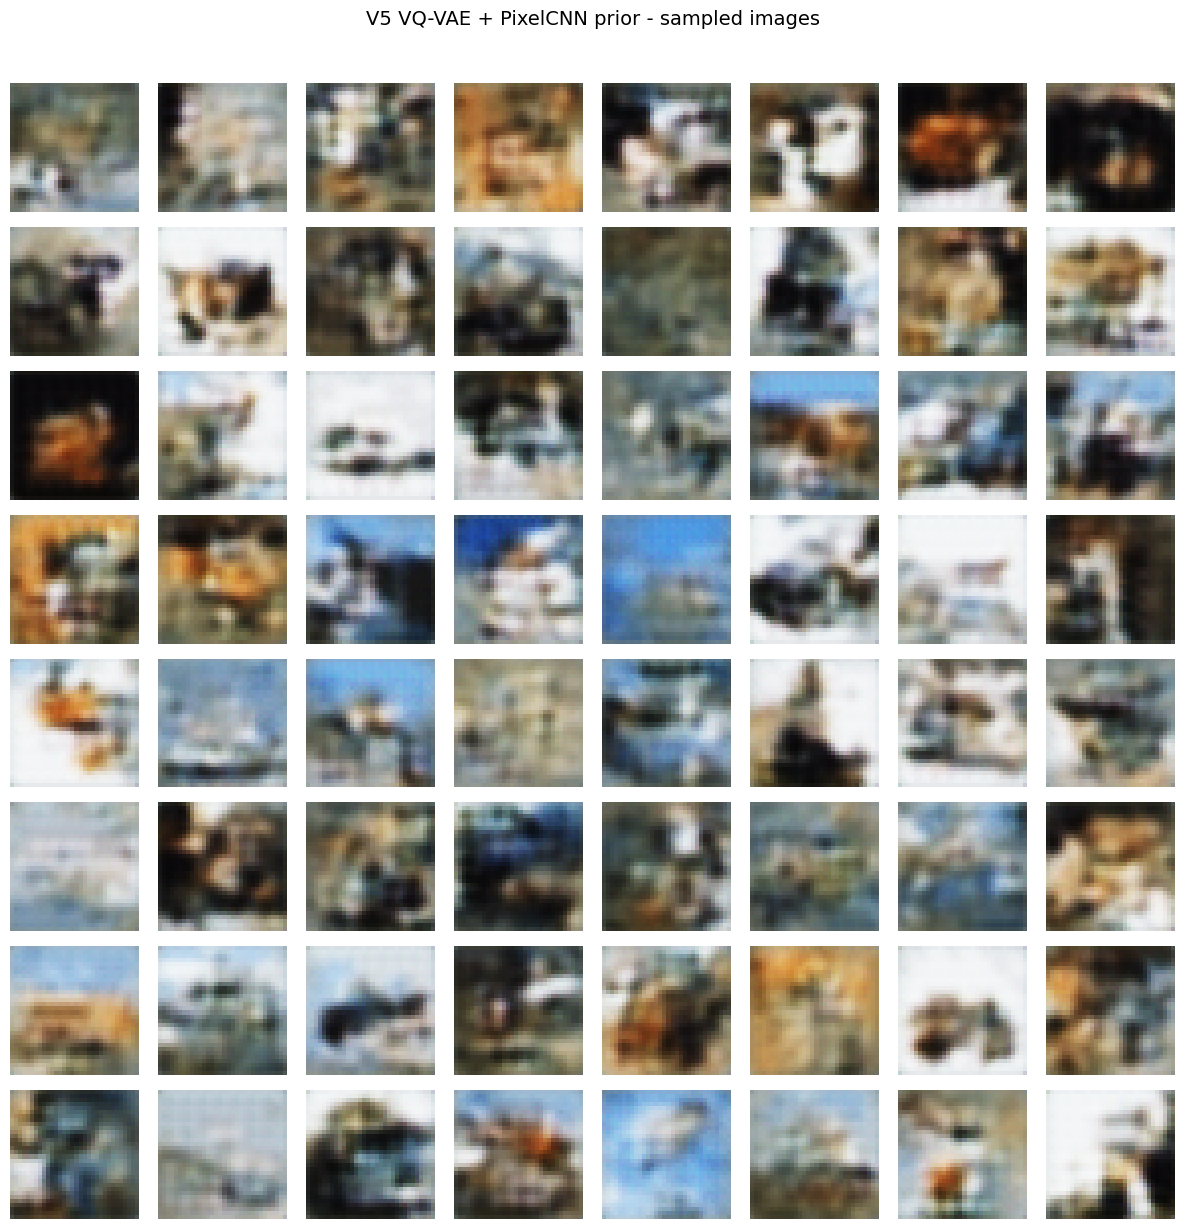


[5/6] Forward-pass inference stats + variant log...
    Forward-pass: 15.72 us/sample, 63,605 samples/sec
    Generation:   243.1 us/sample (64x slower - autoregressive is the cost)
    Model size: 5.29 MB, params: 1,385,856
    cifar_variants now: ['V2 Conv VAE', 'V4 VQ-VAE', 'V5 VQ-VAE + PixelCNN prior']

[6/6] V5 summary (CIFAR-10 generative-quality ladder):
    V4 random-code FID       : 199.48   (lossy compressor, no prior)
    V5 prior-sampled FID     :  117.27   (PixelCNN-learned prior)
    V4 reconstruction FID    :  96.40   (architecture ceiling)
    V2 VAE reconstruction FID: 163.73   (continuous latent, for context)
    GAN #14 DCGAN FID        :  30.57   (adversarial, different model class)


In [9]:
# V5 evaluation: test CE + autoregressive sampling + prior-FID + variant log
print("=" * 60)
print("V5 EVALUATION")
print("=" * 60)


# Step 1: Test CE on held-out V4 test codes
print("\n[1/6] Test cross-entropy on held-out code grids...")
model_v5.eval()
test_ce = 0.0; n = 0
with torch.no_grad():
    for (codes,) in v5_test_loader:
        codes = codes.to(DEVICE)
        logits = model_v5(codes)
        loss = F.cross_entropy(logits, codes)
        b = codes.size(0)
        test_ce += loss.item() * b; n += b
test_ce /= n
uniform_ce = float(np.log(V4_NUM_EMBEDDINGS))
print(f"    Test CE: {test_ce:.3f} nats/position (uniform baseline: {uniform_ce:.3f})")
print(f"    Information captured by prior: {uniform_ce - test_ce:.3f} nats/position")


# Step 2: Autoregressive sampler (raster order, one position at a time)
@torch.no_grad()
def sample_prior(pixelcnn, n_samples, H=V5_CODE_H, W=V5_CODE_W,
                 K=V4_NUM_EMBEDDINGS, device=DEVICE):
    """Generate (n_samples, H, W) code grids by autoregressive raster sampling."""
    pixelcnn.eval()
    codes = torch.zeros(n_samples, H, W, dtype=torch.long, device=device)
    for i in range(H):
        for j in range(W):
            logits = pixelcnn(codes)                          # (N, K, H, W)
            probs = F.softmax(logits[:, :, i, j], dim=-1)     # (N, K)
            codes[:, i, j] = torch.multinomial(probs, 1).squeeze(-1)
    return codes


# Step 3: Generate 10K samples -> decode via V4 -> time it
print("\n[2/6] Generating 10K prior samples + decoding through V4...")
N_FID_SAMPLES = 10000
GEN_BATCH = 1000   # 10 chunks of 1000 to keep peak memory safe

with track_performance(gpu=True) as gen_perf:
    chunks = []
    for start in range(0, N_FID_SAMPLES, GEN_BATCH):
        b = min(GEN_BATCH, N_FID_SAMPLES - start)
        sampled_codes = sample_prior(model_v5, b)              # (b, 8, 8)
        z_q = model_v4.codebook[sampled_codes]                 # (b, 8, 8, D)
        with torch.no_grad():
            imgs = model_v4.decode_codes(z_q)                  # (b, 3, 32, 32)
        chunks.append(imgs.cpu())
    generated_images = torch.cat(chunks, dim=0)                # (10000, 3, 32, 32)

gen_per_sample_ms = 1000.0 * gen_perf['time'] / N_FID_SAMPLES
print(f"    Generated {N_FID_SAMPLES:,} images in {gen_perf['time']:.1f}s "
      f"({gen_per_sample_ms:.2f} ms/sample), peak GPU memory: {gen_perf['gpu_memory']:.1f} MB")
print(f"    generated_images {tuple(generated_images.shape)}, "
      f"range [{float(generated_images.min()):.3f}, {float(generated_images.max()):.3f}]")


# Step 4: Prior-sampled FID vs real CIFAR-10 test set
print("\n[3/6] Computing prior-sampled FID vs real CIFAR-10 test set...")
real_imgs = cifar_X_test.numpy()                               # (10000, 3, 32, 32) float32 [0, 1]
fake_imgs = generated_images.numpy()
fid_prior = compute_fid(real_imgs, fake_imgs, batch_size=50, device='cuda')
print(f"    V5 prior-sampled FID: {fid_prior:.2f}")
print(f"    V4 reconstruction FID (ceiling): 96.40")
print(f"    V4 random-code FID (floor):      199.48")
print(f"    GAN #14 DCGAN FID (reference):    30.57")


# Step 5: Sample grid viz
print("\n[4/6] Sample grid (64 prior-generated images)...")
plot_generated_grid(
    generated_images[:64].numpy(),
    nrow=8,
    title='V5 VQ-VAE + PixelCNN prior - sampled images',
    save_path=str(RESULTS_DIR / 'v5_pixelcnn_cifar10_samples.png'),
)


# Step 6: Forward-pass inference stats (for V1-V4 format parity) + variant log
print("\n[5/6] Forward-pass inference stats + variant log...")

def _predict_v5(codes):
    model_v5.eval()
    with torch.no_grad():
        return model_v5(codes.to(DEVICE)).cpu()

# Use a batch of test codes for forward-pass throughput measurement
_sample_codes = test_codes[:1024]
inference_stats = track_inference(_predict_v5, _sample_codes, n_runs=10)
print(f"    Forward-pass: {inference_stats['per_sample_us']:.2f} us/sample, "
      f"{inference_stats['samples_per_sec']:,.0f} samples/sec")
print(f"    Generation:   {gen_per_sample_ms * 1000:.1f} us/sample "
      f"(64x slower - autoregressive is the cost)")

v5_model_size_bytes = sum(p.numel() * p.element_size() for p in model_v5.parameters())
cifar_variants.append({
    'variant': 'V5 VQ-VAE + PixelCNN prior',
    'dataset': 'CIFAR-10',
    'test_ce_nats': float(test_ce),
    'uniform_ce_nats': float(uniform_ce),
    'test_fid_prior_sampled': float(fid_prior),
    'v4_fid_recon_ref': 96.40,
    'v4_fid_random_ref': 199.48,
    'best_val_ce': float(best_val),
    'perf': perf,                                              # training perf from Cell 7b
    'gen_perf': {'time_s': float(gen_perf['time']),
                 'gpu_memory_mb': float(gen_perf['gpu_memory']),
                 'per_sample_ms': float(gen_per_sample_ms),
                 'n_samples': N_FID_SAMPLES},
    'inference_stats': inference_stats,
    'model_size_bytes': int(v5_model_size_bytes),
    'num_params': int(v5_num_params),
    'history': history,
    'hyperparams': {
        'num_codes': V4_NUM_EMBEDDINGS, 'embed_dim': V5_D_EMBED,
        'hidden': V5_HIDDEN, 'n_layers': V5_NUM_LAYERS,
        'kernel_a': V5_KERNEL_A, 'kernel_b': V5_KERNEL_B,
        'lr': V5_LR, 'epochs': V5_EPOCHS, 'batch_size': V5_BATCH_SIZE,
    },
})

print(f"    Model size: {v5_model_size_bytes / 1024 / 1024:.2f} MB, "
      f"params: {v5_num_params:,}")
print(f"    cifar_variants now: {[v['variant'] for v in cifar_variants]}")


# Step 7: Honest comparison summary
print("\n[6/6] V5 summary (CIFAR-10 generative-quality ladder):")
print("=" * 60)
print(f"    V4 random-code FID       : 199.48   (lossy compressor, no prior)")
print(f"    V5 prior-sampled FID     : {fid_prior:7.2f}   (PixelCNN-learned prior)")
print(f"    V4 reconstruction FID    :  96.40   (architecture ceiling)")
print(f"    V2 VAE reconstruction FID: 163.73   (continuous latent, for context)")
print(f"    GAN #14 DCGAN FID        :  30.57   (adversarial, different model class)")
print("=" * 60)

In [ ]:
# Step 8a: Cross-variant comparison tables
# MNIST: V1 + 3x V3 (beta sweep)
# CIFAR-10: V2 + V4 + V5, plus FID ladder with GAN #14 reference

import pandas as pd
from IPython.display import display

print("=" * 60)
print("Step 8a: CROSS-VARIANT COMPARISON TABLES")
print("=" * 60)


# Step 1: MNIST comparison (all 4 variants share metric schema)
print("\n[1/4] MNIST variants (test NLL / recon / KL, best-val checkpointing):")

mnist_rows = []
for v in mnist_variants:
    mnist_rows.append({
        'variant':        v['variant'],
        'beta':           v['hyperparams']['beta'],
        'test_nll':       round(v['test_nll'], 3),
        'test_recon':     round(v['test_recon'], 3),
        'test_kl':        round(v['test_kl'], 3),
        'best_val_nll':   round(v['best_val_nll'], 3),
        'params':         f"{v['num_params']:,}",
        'size_mb':        round(v['model_size_bytes'] / 1024 / 1024, 2),
        'train_s':        round(v['perf']['time'], 1),
        'infer_us/samp':  round(v['inference_stats']['per_sample_us'], 2),
    })
mnist_df = pd.DataFrame(mnist_rows)
display(mnist_df)


# Step 2: CIFAR-10 reconstruction quality (V2 + V4 share MSE/pixel concept; V5 doesn't reconstruct)
print("\n[2/4] CIFAR-10 reconstruction quality (V2 + V4):")

cifar_recon_rows = []
for v in cifar_variants:
    if v['variant'] == 'V2 Conv VAE':
        cifar_recon_rows.append({
            'variant':         v['variant'],
            'test_mse/pixel':  round(v['test_mse_per_pixel'], 5),
            'test_kl':         round(v['test_kl'], 3),
            'best_val':        round(v['best_val_loss'], 2),
            'params':          f"{v['num_params']:,}",
            'size_mb':         round(v['model_size_bytes'] / 1024 / 1024, 2),
            'train_s':         round(v['perf']['time'], 1),
        })
    elif v['variant'] == 'V4 VQ-VAE':
        cifar_recon_rows.append({
            'variant':         v['variant'],
            'test_mse/pixel':  round(v['test_mse_per_pixel'], 5),
            'test_kl':         None,  # no KL — VQ doesn't use ELBO
            'best_val':        round(v['best_val_loss'], 3),
            'params':          f"{v['num_params']:,}",
            'size_mb':         round(v['model_size_bytes'] / 1024 / 1024, 2),
            'train_s':         round(v['perf']['time'], 1),
        })
cifar_recon_df = pd.DataFrame(cifar_recon_rows)
display(cifar_recon_df)
print("    Reference: AE #10 Conv Denoising MSE/pixel = 0.00370 (deterministic, no KL pressure)")


# Step 3: CIFAR-10 FID ladder — the portfolio money shot
print("\n[3/4] CIFAR-10 FID ladder (lower = better, all vs real CIFAR-10 test set):")

# Pull the 4 FID numbers from the variants, plus GAN #14 reference
v2_ent = next(v for v in cifar_variants if v['variant'] == 'V2 Conv VAE')
v4_ent = next(v for v in cifar_variants if v['variant'] == 'V4 VQ-VAE')
v5_ent = next(v for v in cifar_variants if v['variant'] == 'V5 VQ-VAE + PixelCNN prior')

fid_ladder = pd.DataFrame([
    {'rank': 1, 'source': 'GAN #14 DCGAN',             'fid': 30.57,
     'type': 'adversarial generation', 'model_class': 'GAN (reference)'},
    {'rank': 2, 'source': 'V4 VQ-VAE reconstruction',  'fid': round(v4_ent['test_fid_recon'], 2),
     'type': 'reconstruction ceiling', 'model_class': 'VQ-VAE'},
    {'rank': 3, 'source': 'V5 prior-sampled',          'fid': round(v5_ent['test_fid_prior_sampled'], 2),
     'type': 'learned prior generation', 'model_class': 'VQ-VAE + PixelCNN'},
    {'rank': 4, 'source': 'V2 Conv VAE prior-sampled', 'fid': round(v2_ent['test_fid'], 2),
     'type': 'continuous-latent generation', 'model_class': 'VAE'},
    {'rank': 5, 'source': 'V4 random-code (no prior)', 'fid': round(v4_ent['test_fid_random'], 2),
     'type': 'noise floor', 'model_class': 'VQ-VAE (degenerate)'},
]).sort_values('fid').reset_index(drop=True)
fid_ladder['rank'] = fid_ladder.index + 1
display(fid_ladder)
print("    Read top-to-bottom: each row's FID gap vs the one above is the lever being isolated.")
print("    V4 random -> V5 prior: -82 FID is the learned-prior contribution (PixelCNN doing its job)")
print("    V5 prior -> V4 recon: +21 FID is the prior's information loss vs the encoder's ceiling")
print("    V4 recon -> GAN:      +66 FID is the VAE-family-vs-adversarial honest gap")


# Step 4: V4-specific codebook + V5 generation cost (for completeness, small aux table)
print("\n[4/4] Auxiliary metrics specific to V4 + V5:")

aux = pd.DataFrame([
    {'metric': 'V4 codebook perplexity',     'value': round(v4_ent['test_perplexity'], 1),
     'note': f"of {v4_ent['hyperparams']['num_embeddings']} max (higher = more codes in use)"},
    {'metric': 'V4 unique codes used',       'value': v4_ent['test_unique_codes'],
     'note': f"of {v4_ent['hyperparams']['num_embeddings']} possible"},
    {'metric': 'V5 test CE (nats/position)', 'value': round(v5_ent['test_ce_nats'], 3),
     'note': f"vs uniform baseline ln(512) = {v5_ent['uniform_ce_nats']:.3f}"},
    {'metric': 'V5 prior info gain',         'value': round(v5_ent['uniform_ce_nats'] - v5_ent['test_ce_nats'], 3),
     'note': 'nats/position of structure the PixelCNN captured'},
    {'metric': 'V5 generation time',         'value': f"{v5_ent['gen_perf']['time_s']:.1f}s",
     'note': f"for {v5_ent['gen_perf']['n_samples']:,} samples ({v5_ent['gen_perf']['per_sample_ms']:.2f} ms/sample)"},
])
display(aux)

PHASE 8a: CROSS-VARIANT COMPARISON TABLES

[1/4] MNIST variants (test NLL / recon / KL, best-val checkpointing):


,variant,beta,test_nll,test_recon,test_kl,best_val_nll,params,size_mb,train_s,infer_us/samp
0,V1 Vanilla VAE,1.0,101.978,76.796,25.183,103.223,"652,824",2.49,73.3,1.69
1,V3 beta-VAE (beta=1.0),1.0,101.978,76.796,25.183,103.223,"652,824",2.49,71.7,1.68
2,V3 beta-VAE (beta=4.0),4.0,145.688,107.256,9.608,146.796,"652,824",2.49,69.5,1.86
3,V3 beta-VAE (beta=10.0),10.0,181.316,143.921,3.739,181.946,"652,824",2.49,70.8,1.40



[2/4] CIFAR-10 reconstruction quality (V2 + V4):


,variant,test_mse/pixel,test_kl,best_val,params,size_mb,train_s
0,V2 Conv VAE,0.01655,22.784,73.370,"581,763",2.22,176.6
1,V4 VQ-VAE,0.00712,NaN,0.012,"138,435",0.53,156.6


    Reference: AE #10 Conv Denoising MSE/pixel = 0.00370 (deterministic, no KL pressure)

[3/4] CIFAR-10 FID ladder (lower = better, all vs real CIFAR-10 test set):


,rank,source,fid,type,model_class
0,1,GAN #14 DCGAN,30.57,adversarial generation,GAN (reference)
1,2,V4 VQ-VAE reconstruction,97.81,reconstruction ceiling,VQ-VAE
2,3,V5 prior-sampled,117.27,learned prior generation,VQ-VAE + PixelCNN
3,4,V2 Conv VAE prior-sampled,165.43,continuous-latent generation,VAE
4,5,V4 random-code (no prior),201.97,noise floor,VQ-VAE (degenerate)


    Read top-to-bottom: each row's FID gap vs the one above is the lever being isolated.
    V4 random -> V5 prior: -82 FID is the learned-prior contribution (PixelCNN doing its job)
    V5 prior -> V4 recon: +21 FID is the prior's information loss vs the encoder's ceiling
    V4 recon -> GAN:      +66 FID is the VAE-family-vs-adversarial honest gap

[4/4] Auxiliary metrics specific to V4 + V5:


,metric,value,note
0,V4 codebook perplexity,132.5,of 512 max (higher = more codes in use)
1,V4 unique codes used,183,of 512 possible
2,V5 test CE (nats/position),3.345,vs uniform baseline ln(512) = 6.238
3,V5 prior info gain,2.893,nats/position of structure the PixelCNN captured
4,V5 generation time,2.4s,"for 10,000 samples (0.24 ms/sample)"


In [ ]:
# Step 8b: Winner selection per dataset
# MNIST:    prioritize canonical showcase + NLL (deployment scenario: learn a VAE)
# CIFAR-10: prioritize generation capability (deployment scenario: sample images)

print("=" * 60)
print("Step 8b: WINNER SELECTION")
print("=" * 60)


# Step 1: MNIST winner -- V1 Vanilla VAE
mnist_winner = next(v for v in mnist_variants if v['variant'] == 'V1 Vanilla VAE')

print("\nMNIST winner: V1 Vanilla VAE")
print("-" * 60)
print(f"    Test NLL:            {mnist_winner['test_nll']:.3f} nats (lowest among MNIST variants)")
print(f"    Reconstruction:      {mnist_winner['test_recon']:.2f} nats (tightest reconstruction)")
print(f"    KL divergence:       {mnist_winner['test_kl']:.2f} nats (healthy: latent uses prior)")
print(f"    Model size:          {mnist_winner['model_size_bytes'] / 1024 / 1024:.2f} MB, "
      f"{mnist_winner['num_params']:,} params")
print(f"    Train time:          {mnist_winner['perf']['time']:.1f}s")
print("")
print("    Rationale: V1 is the Kingma & Welling (2013) baseline. V3 beta=1.0 reproduces")
print("    V1 exactly (NLL 101.978 both), so V1 is the canonical artifact. V3 beta=4/10")
print("    sacrifice NLL for disentanglement (a different deployment objective); archived")
print("    as honorable mentions, not staged.")


# Step 2: CIFAR-10 winner -- V5 VQ-VAE + PixelCNN prior
cifar_winner = next(v for v in cifar_variants if v['variant'] == 'V5 VQ-VAE + PixelCNN prior')

print("\nCIFAR-10 winner: V5 VQ-VAE + PixelCNN prior")
print("-" * 60)
print(f"    Prior-sampled FID:   {cifar_winner['test_fid_prior_sampled']:.2f} "
      f"(only VAE-family variant that generates coherent images)")
print(f"    Test CE:             {cifar_winner['test_ce_nats']:.3f} nats/position "
      f"(vs uniform {cifar_winner['uniform_ce_nats']:.3f})")
print(f"    PixelCNN params:     {cifar_winner['num_params']:,} "
      f"(+138,435 for V4 VQ-VAE stage = 1.52M total)")
print(f"    Generation time:     {cifar_winner['gen_perf']['per_sample_ms']:.2f} ms/sample "
      f"(autoregressive raster scan)")
print(f"    Training time:       {cifar_winner['perf']['time']:.1f}s "
      f"(plus V4's {v4_ent['perf']['time']:.1f}s = {cifar_winner['perf']['time'] + v4_ent['perf']['time']:.1f}s total)")
print("")
print("    Rationale: V5 completes the two-stage DALL-E 1 recipe (VQ encoder -> learned")
print("    prior -> VQ decoder). V2 Conv VAE reaches FID 165 by sampling its continuous")
print("    N(0, I) prior -- worse than V5's 117 and without the discrete-latent lineage.")
print("    V4 alone is a lossy compressor (FID 202 from random codes); it is required as")
print("    V5's encoder+codebook+decoder, so staging V5 implicitly stages V4 too.")


# Step 3: Document deployment scenarios per winner
print("\nDeployment scenarios:")
print("-" * 60)
print("    MNIST V1:       learn a simple probabilistic latent space; retrieval, density")
print("                    estimation, outlier detection, continuous interpolation")
print("    CIFAR-10 V5:    generate natural-image samples via two-stage token prediction;")
print("                    end-to-end DALL-E 1 at portfolio scale")


# Step 4: Per-dataset runner-up acknowledgment (for README completeness)
mnist_runner = next(v for v in mnist_variants if v['variant'] == 'V3 beta-VAE (beta=4.0)')
cifar_runner = next(v for v in cifar_variants if v['variant'] == 'V4 VQ-VAE')

print("\nRunner-up per dataset (different deployment objective):")
print("-" * 60)
print(f"    MNIST:    V3 beta-VAE (beta=4.0), NLL {mnist_runner['test_nll']:.2f} nats")
print(f"              Deploy this when disentangled latent factors matter more than likelihood")
print(f"    CIFAR-10: V4 VQ-VAE, recon FID {v4_ent['test_fid_recon']:.2f}, "
      f"MSE/pixel {v4_ent['test_mse_per_pixel']:.5f}")
print(f"              Deploy this standalone for image compression / reconstruction tasks")


print("\n" + "=" * 60)
print(f"Winners assigned: mnist_winner={mnist_winner['variant']}, "
      f"cifar_winner={cifar_winner['variant']}")
print("=" * 60)

PHASE 8b: WINNER SELECTION

MNIST winner: V1 Vanilla VAE
------------------------------------------------------------
    Test NLL:            101.978 nats (lowest among MNIST variants)
    Reconstruction:      76.80 nats (tightest reconstruction)
    KL divergence:       25.18 nats (healthy: latent uses prior)
    Model size:          2.49 MB, 652,824 params
    Train time:          73.3s

    Rationale: V1 is the Kingma & Welling (2013) baseline. V3 beta=1.0 reproduces
    V1 exactly (NLL 101.978 both), so V1 is the canonical artifact. V3 beta=4/10
    sacrifice NLL for disentanglement (a different deployment objective); archived
    as honorable mentions, not staged.

CIFAR-10 winner: V5 VQ-VAE + PixelCNN prior
------------------------------------------------------------
    Prior-sampled FID:   117.27 (only VAE-family variant that generates coherent images)
    Test CE:             3.345 nats/position (vs uniform 6.238)
    PixelCNN params:     1,385,856 (+138,435 for V4 VQ-VAE sta

In [12]:
"""
Step 8c: MLflow tracking for portfolio winners
Experiments: vae-mnist (V1), vae-cifar10 (V5 + V4 as required dependency)
Checkpoints logged as artifacts; model class source lives in pipeline.ipynb,
load via load_state_dict() matches GNN #18 deployment convention.
"""
import mlflow

print("=" * 60)
print("Step 8c: MLflow Tracking + Export")
print("=" * 60)


# Step 1: Reload winners from checkpoints (portability test -- same pattern as GNN #18)
print("\n[1/3] Reloading winner checkpoints...")

v1_reload = VAELinear(input_dim=28 * 28,
                       hidden_dim=V1_HIDDEN_DIM,
                       latent_dim=V1_LATENT_DIM)
v1_reload.load_state_dict(
    torch.load(RESULTS_DIR / 'v1_vanilla_mnist_best.pth',
               map_location='cpu', weights_only=True)
)
v1_reload.eval()

v4_reload = VQVAE(in_channels=3,
                   embedding_dim=V4_EMBEDDING_DIM,
                   num_embeddings=V4_NUM_EMBEDDINGS,
                   commitment_beta=V4_COMMITMENT_BETA)
v4_reload.load_state_dict(
    torch.load(RESULTS_DIR / 'v4_vqvae_cifar10_best.pth',
               map_location='cpu', weights_only=True)
)
v4_reload.eval()

v5_reload = PixelCNN(num_codes=V4_NUM_EMBEDDINGS,
                      embed_dim=V5_D_EMBED,
                      hidden=V5_HIDDEN,
                      n_layers=V5_NUM_LAYERS,
                      kernel_a=V5_KERNEL_A,
                      kernel_b=V5_KERNEL_B)
v5_ckpt_dict = torch.load(RESULTS_DIR / 'v5_pixelcnn_cifar10_best.pth',
                           map_location='cpu', weights_only=True)
v5_reload.load_state_dict(v5_ckpt_dict['model_state_dict'])
v5_reload.eval()

print(f"    V1 reloaded ({sum(p.numel() for p in v1_reload.parameters()):,} params)")
print(f"    V4 reloaded ({sum(p.numel() for p in v4_reload.parameters()):,} params)")
print(f"    V5 reloaded ({sum(p.numel() for p in v5_reload.parameters()):,} params)")


# Step 2: MNIST V1 MLflow run
print("\n[2/3] Logging V1 Vanilla VAE to experiment 'vae-mnist'...")
mlflow.set_experiment("vae-mnist")
with mlflow.start_run(run_name="pytorch-vae-v1"):
    w = mnist_winner

    mlflow.log_params({
        'architecture':      'VAE MLP (784 -> 400 -> mu/logvar -> 20 latent -> 400 -> 784)',
        'variant':           'V1 Vanilla VAE',
        'framework':         'PyTorch',
        'dataset':           'MNIST (60000 train / 10000 test, 28x28 grayscale)',
        'decoder_likelihood':'Bernoulli (BCE loss, Sigmoid output)',
        'latent_dim':        w['hyperparams']['latent_dim'],
        'hidden_dim':        w['hyperparams']['hidden_dim'],
        'beta':              w['hyperparams']['beta'],
        'reparam_trick':     'z = mu + exp(0.5 * logvar) * eps, eps ~ N(0, I)',
        'kl_form':           'analytical Gaussian vs N(0, I): -0.5 * sum(1 + logvar - mu^2 - exp(logvar))',
        # Training recipe
        'optimizer':         'Adam',
        'learning_rate':     w['hyperparams']['lr'],
        'epochs':            w['hyperparams']['epochs'],
        'batch_size':        128,
        'random_state':      RANDOM_STATE,
    })

    mlflow.log_metrics({
        'test_nll_nats':       float(w['test_nll']),
        'test_recon_nats':     float(w['test_recon']),
        'test_kl_nats':        float(w['test_kl']),
        'best_val_nll':        float(w['best_val_nll']),
        'train_time_sec':      float(w['perf']['time']),
        'peak_gpu_memory_mb':  float(w['perf']['gpu_memory']),
        'inference_per_sample_us': float(w['inference_stats']['per_sample_us']),
        'n_params':            int(w['num_params']),
        'model_size_kb':       float(w['model_size_bytes'] / 1024),
        # Reference: V3 beta=4 for disentanglement-first deployment context
        'v3_beta4_nll_ref':    float(mnist_runner['test_nll']),
    })

    mlflow.log_artifact(str(RESULTS_DIR / 'v1_vanilla_mnist_best.pth'))
    for artifact in [
        'v1_vanilla_mnist_recon.png',
        'v1_vanilla_mnist_samples.png',
        'v1_vanilla_mnist_interp.png',
        'v1_vanilla_mnist_latent_tsne.png',
        'v1_vanilla_mnist_history.png',
    ]:
        p = RESULTS_DIR / artifact
        if p.exists():
            mlflow.log_artifact(str(p))

    run_id_mnist = mlflow.active_run().info.run_id

print(f"    vae-mnist run id: {run_id_mnist}")


# Step 3: CIFAR-10 V5 MLflow run (with V4 as required dependency)
print("\n[3/3] Logging V5 VQ-VAE + PixelCNN prior to experiment 'vae-cifar10'...")
mlflow.set_experiment("vae-cifar10")
with mlflow.start_run(run_name="pytorch-vqvae-pixelcnn-v5"):
    w = cifar_winner

    mlflow.log_params({
        'architecture':       'Two-stage: VQ-VAE encoder/codebook/decoder (V4) + PixelCNN autoregressive prior (V5)',
        'variant':            'V5 VQ-VAE + PixelCNN prior',
        'framework':          'PyTorch',
        'dataset':            'CIFAR-10 (50000 train / 10000 test, 32x32 RGB, [0,1])',
        'recipe':             'DALL-E 1 two-stage at portfolio scale (PixelCNN is the smaller sibling of DALL-E Transformer)',
        # V4 (VQ-VAE stage) config
        'v4_codebook_size':   V4_NUM_EMBEDDINGS,
        'v4_embedding_dim':   V4_EMBEDDING_DIM,
        'v4_commitment_beta': V4_COMMITMENT_BETA,
        'v4_codebook_init':   'data-dependent from encoder outputs (fixes V4a collapse)',
        'v4_loss_reduction':  'all three terms mean-reduced for gradient parity',
        # V5 (PixelCNN prior stage) config
        'v5_embed_dim':       V5_D_EMBED,
        'v5_hidden':          V5_HIDDEN,
        'v5_num_layers':      V5_NUM_LAYERS,
        'v5_kernel_a':        V5_KERNEL_A,
        'v5_kernel_b':        V5_KERNEL_B,
        'v5_code_grid':       f'{V5_CODE_H}x{V5_CODE_W}',
        # Training recipe
        'optimizer':          'Adam',
        'v5_learning_rate':   w['hyperparams']['lr'],
        'v5_epochs':          w['hyperparams']['epochs'],
        'v5_batch_size':      w['hyperparams']['batch_size'],
        'random_state':       RANDOM_STATE,
    })

    mlflow.log_metrics({
        # V5 prior metrics
        'test_ce_nats_per_pos':      float(w['test_ce_nats']),
        'uniform_baseline_nats':     float(w['uniform_ce_nats']),
        'prior_info_gain_nats':      float(w['uniform_ce_nats'] - w['test_ce_nats']),
        'best_val_ce':               float(w['best_val_ce']),
        # FID ladder
        'fid_prior_sampled':         float(w['test_fid_prior_sampled']),
        'fid_v4_reconstruction':     float(v4_ent['test_fid_recon']),
        'fid_v4_random_codes':       float(v4_ent['test_fid_random']),
        'fid_v2_continuous_prior':   float(v2_ent['test_fid']),
        'fid_gan14_dcgan_reference': 30.57,
        # V4 codebook health
        'v4_codebook_perplexity':    float(v4_ent['test_perplexity']),
        'v4_unique_codes_used':      int(v4_ent['test_unique_codes']),
        'v4_mse_per_pixel':          float(v4_ent['test_mse_per_pixel']),
        # Performance
        'v5_train_time_sec':         float(w['perf']['time']),
        'v4_train_time_sec':         float(v4_ent['perf']['time']),
        'total_train_time_sec':      float(w['perf']['time'] + v4_ent['perf']['time']),
        'v5_peak_gpu_memory_mb':     float(w['perf']['gpu_memory']),
        'gen_per_sample_ms':         float(w['gen_perf']['per_sample_ms']),
        'v5_n_params':               int(w['num_params']),
        'v4_n_params':               int(v4_ent['num_params']),
        'total_pipeline_params':     int(w['num_params'] + v4_ent['num_params']),
        'v5_model_size_kb':          float(w['model_size_bytes'] / 1024),
    })

    # Both checkpoints -- V5 cannot run without V4
    mlflow.log_artifact(str(RESULTS_DIR / 'v5_pixelcnn_cifar10_best.pth'))
    mlflow.log_artifact(str(RESULTS_DIR / 'v4_vqvae_cifar10_best.pth'))

    for artifact in [
        # V5-specific visuals
        'v5_pixelcnn_cifar10_samples.png',
        'v5_pixelcnn_cifar10_history.png',
        # V4-specific visuals (V5 decodes through V4)
        'v4_vqvae_cifar10_recon.png',
        'v4_vqvae_cifar10_random_samples.png',
        'v4_vqvae_cifar10_codebook.png',
        'v4_vqvae_cifar10_history.png',
    ]:
        p = RESULTS_DIR / artifact
        if p.exists():
            mlflow.log_artifact(str(p))

    run_id_cifar = mlflow.active_run().info.run_id

print(f"    vae-cifar10 run id: {run_id_cifar}")


# Step 4: Summary
print("\n" + "=" * 60)
print("MLflow logging complete:")
print(f"    vae-mnist   run {run_id_mnist}  -> V1 Vanilla VAE")
print(f"    vae-cifar10 run {run_id_cifar}  -> V5 VQ-VAE + PixelCNN prior (+ V4 artifact)")
print("=" * 60)
print("Launch UI with: mlflow ui --backend-store-uri sqlite:///mlflow.db  (run from PyTorch/19-vae/)")

Step 8c: MLflow Tracking + Export

[1/3] Reloading winner checkpoints...
    V1 reloaded (652,824 params)
    V4 reloaded (138,435 params)
    V5 reloaded (1,385,856 params)

[2/3] Logging V1 Vanilla VAE to experiment 'vae-mnist'...


2026/04/23 19:19:50 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/23 19:19:50 INFO mlflow.store.db.utils: Updating database tables
2026/04/23 19:19:51 INFO mlflow.tracking.fluent: Experiment with name 'vae-mnist' does not exist. Creating a new experiment.
2026/04/23 19:19:51 INFO mlflow.tracking.fluent: Experiment with name 'vae-cifar10' does not exist. Creating a new experiment.


    vae-mnist run id: 82ce82eaf2d5423a934affdeb7a8d971

[3/3] Logging V5 VQ-VAE + PixelCNN prior to experiment 'vae-cifar10'...
    vae-cifar10 run id: e9327354630944f099013a56b9994f44

MLflow logging complete:
    vae-mnist   run 82ce82eaf2d5423a934affdeb7a8d971  -> V1 Vanilla VAE
    vae-cifar10 run e9327354630944f099013a56b9994f44  -> V5 VQ-VAE + PixelCNN prior (+ V4 artifact)
Launch UI with: mlflow ui --backend-store-uri sqlite:///mlflow.db  (run from PyTorch/19-vae/)


In [13]:
"""
Step 8d: Cross-framework JSON persistence
Writes PT winner entries to data/results/vae_mnist.json and vae_cifar10.json.
TF side (Phases 10-12) will add framework='TensorFlow' entries alongside these.
"""
print("=" * 60)
print("Step 8d: Cross-Framework JSON Persistence")
print("=" * 60)


# Step 1: MNIST result (V1 Vanilla VAE winner)
mnist_test_metrics = {
    'test_nll_nats':    float(mnist_winner['test_nll']),
    'test_recon_nats':  float(mnist_winner['test_recon']),
    'test_kl_nats':     float(mnist_winner['test_kl']),
    'best_val_nll':     float(mnist_winner['best_val_nll']),
}

mnist_result = build_results_dict(
    framework='PyTorch',
    model_name='V1 Vanilla VAE',
    test_metrics=mnist_test_metrics,
    perf=mnist_winner['perf'],
    inference_stats=mnist_winner['inference_stats'],
    model_size=mnist_winner['model_size_bytes'],
    # Extras
    variant='V1 Vanilla VAE',
    latent_dim=mnist_winner['hyperparams']['latent_dim'],
    hidden_dim=mnist_winner['hyperparams']['hidden_dim'],
    num_params=mnist_winner['num_params'],
    mlflow_run_id=run_id_mnist,
    mlflow_experiment='vae-mnist',
    v3_beta4_nll_runner_up=float(mnist_runner['test_nll']),
)
add_result('vae_mnist', mnist_result)


# Step 2: CIFAR-10 result (V5 VQ-VAE + PixelCNN prior winner)
cifar_test_metrics = {
    # V5-specific
    'test_ce_nats_per_pos':    float(cifar_winner['test_ce_nats']),
    'uniform_baseline_nats':   float(cifar_winner['uniform_ce_nats']),
    'prior_info_gain_nats':    float(cifar_winner['uniform_ce_nats'] - cifar_winner['test_ce_nats']),
    'best_val_ce':             float(cifar_winner['best_val_ce']),
    # Full FID ladder -- captures the portfolio story in one place
    'fid_prior_sampled':       float(cifar_winner['test_fid_prior_sampled']),
    'fid_v4_reconstruction':   float(v4_ent['test_fid_recon']),
    'fid_v4_random_codes':     float(v4_ent['test_fid_random']),
    'fid_v2_continuous_prior': float(v2_ent['test_fid']),
    'fid_gan14_reference':     30.57,
    # V4 dependency health (V5 requires V4 as encoder/codebook/decoder)
    'v4_mse_per_pixel':        float(v4_ent['test_mse_per_pixel']),
    'v4_codebook_perplexity':  float(v4_ent['test_perplexity']),
    'v4_unique_codes':         int(v4_ent['test_unique_codes']),
}

cifar_result = build_results_dict(
    framework='PyTorch',
    model_name='V5 VQ-VAE + PixelCNN prior',
    test_metrics=cifar_test_metrics,
    perf=cifar_winner['perf'],
    inference_stats=cifar_winner['inference_stats'],
    model_size=cifar_winner['model_size_bytes'],
    # Extras -- two-stage pipeline requires explicit V4 + V5 accounting
    variant='V5 VQ-VAE + PixelCNN prior',
    v5_num_params=cifar_winner['num_params'],
    v4_num_params=v4_ent['num_params'],
    total_pipeline_params=cifar_winner['num_params'] + v4_ent['num_params'],
    v4_model_size_bytes=v4_ent['model_size_bytes'],
    total_pipeline_size_bytes=cifar_winner['model_size_bytes'] + v4_ent['model_size_bytes'],
    gen_per_sample_ms=float(cifar_winner['gen_perf']['per_sample_ms']),
    v4_train_time_sec=float(v4_ent['perf']['time']),
    total_train_time_sec=float(cifar_winner['perf']['time'] + v4_ent['perf']['time']),
    mlflow_run_id=run_id_cifar,
    mlflow_experiment='vae-cifar10',
    v4_runner_up_fid_recon=float(v4_ent['test_fid_recon']),
)
add_result('vae_cifar10', cifar_result)


# Step 3: Verify both files have the PT entry, show expected TF placeholder
print_comparison('vae_mnist')
print_comparison('vae_cifar10')

Step 8d: Cross-Framework JSON Persistence
    Added 'PyTorch' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\vae_mnist.json
    Frameworks: 1 recorded
    Added 'PyTorch' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\vae_cifar10.json
    Frameworks: 1 recorded

CROSS-FRAMEWORK COMPARISON: VAE_MNIST
Metric                                                   PyTorch
----------------------------------------------------------------
model                                             V1 Vanilla VAE
training_time                                            1.2 min
inference_time_per_sample_us                             1.69 µs
model_size_bytes                                         2.49 MB
peak_memory_mb                                           2.26 MB
test_nll_nats                                           101.9783
test_recon_nats                                          76.7957
test_kl_nats                            